# **Crime Prediction in London's 4,835 LSOAs Level Using the Spatio-Temporal Graph Neural Network with Zero-Inflated Negative Binomial Distribution (STGNN-ZINB)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Data Preparation

## 1.1 Crime Types Extraction

Crime types from different crime files of the UK Metropolitan Police are extracted. On average, there are around 30,000 records per month for crime types per LSOA. Firstly, the unique crime types from each file are extracted, and the monthly number of crimes per LSOA code is calculated. Pivot tables are then created based on the different crime types.


In [ ]:
import pandas as pd
import glob
import os
from google.colab import drive

folder_path = '/content/drive/MyDrive/crime_data/'
all_files = glob.glob(f"{folder_path}*.csv")
print(f"Found {len(all_files)} files")

all_data = []
for file in all_files:
    try:
        filename = os.path.basename(file)
        month = None

        for year in range(2016, 2026):   #month extraction
            for m in range(1, 13):
                pattern = f"{year}-{m:02d}"
                if pattern in filename:
                    month = pattern
                    break
            if month:
                break
        if not month:
            print(f"Skipping {filename} - cannot extract month")
            continue


        df = pd.read_csv(file)
        df['Month'] = month

        # columns selection
        if all(col in df.columns for col in ['LSOA code', 'LSOA name', 'Crime type']):
            monthly_summary = df.groupby(['Month', 'LSOA code', 'LSOA name', 'Crime type']).size().reset_index(name='Count')
            all_data.append(monthly_summary)
            print(f"Processed {filename}: {len(monthly_summary)} records")
        else:
            print(f"Skipping {filename} - missing required columns")
    except Exception as e:
        print(f"Error with {file}: {str(e)}")

if all_data:
    combined = pd.concat(all_data, ignore_index=True)

    print(f"\nTotal records processed: {len(combined)}")
    print(f"Unique crime types: {combined['Crime type'].unique()}")
    print(f"Date range: {combined['Month'].min()} to {combined['Month'].max()}")

    final_data = combined.pivot_table(
        index=['Month', 'LSOA code', 'LSOA name'],
        columns='Crime type',
        values='Count',
        aggfunc='sum',
        fill_value=0
    ).reset_index()

    # Calculate total crimes
    crime_columns = [col for col in final_data.columns if col not in ['Month', 'LSOA code', 'LSOA name']]
    final_data['Total Crimes'] = final_data[crime_columns].sum(axis=1)
    final_data.columns = [f"{col}" if col in ['Month', 'LSOA code', 'LSOA name'] else f"{col}" for col in final_data.columns]

    columns_order = ['Month', 'LSOA code', 'LSOA name'] + \
                   [col for col in crime_columns] + \
                   ['Total Crimes']

    final_data = final_data[columns_order]

    output_file = '/content/drive/MyDrive/lsoa_crime_count.csv'
    final_data.to_csv(output_file, index=False)
    print(f"\nFinal summary saved to: {output_file}")
    print(f"Final dataset shape: {final_data.shape}")
    print(f"Columns: {final_data.columns.tolist()}")

    print("\nSample data:")
    print(final_data.head(3))

    print(f"\nStatistics:")
    print(f"Total months: {final_data['Month'].nunique()}")
    print(f"Total LSOA areas: {final_data['LSOA code'].nunique()}")
    print(f"Total crime types: {len(crime_columns)}")
    print(f"Average total crimes per LSOA per month: {final_data['Total Crimes'].mean():.2f}")
else:
    print("No data was processed. Please check your file paths and formats.")

Found 116 files
Processed 2019-01-metropolitan-street.csv: 29764 records
Processed 2019-05-metropolitan-street.csv: 30955 records
Processed 2019-02-metropolitan-street.csv: 29202 records
Processed 2019-03-metropolitan-street.csv: 31094 records
Processed 2019-04-metropolitan-street.csv: 29993 records
Processed 2019-08-metropolitan-street.csv: 29615 records
Processed 2019-09-metropolitan-street.csv: 29398 records
Processed 2019-06-metropolitan-street.csv: 30694 records
Processed 2019-07-metropolitan-street.csv: 30775 records
Processed 2019-10-metropolitan-street.csv: 30654 records
Processed 2020-01-metropolitan-street.csv: 30344 records
Processed 2020-03-metropolitan-street.csv: 29318 records
Processed 2019-11-metropolitan-street.csv: 30060 records
Processed 2020-02-metropolitan-street.csv: 29392 records
Processed 2019-12-metropolitan-street.csv: 29050 records
Processed 2020-07-metropolitan-street.csv: 30926 records
Processed 2020-08-metropolitan-street.csv: 30647 records
Processed 2020-

A total of **3,458,187 crime records** from the UK Metropolitan Police were processed in this analysis. The dataset covers a **date range from January 2016 to August 2025** with various **unique crime types**.

The **14** unique crime types include

1. Bicycle theft
2. Other theft
3. Theft from the person
4. Anti-social behaviour
5. Vehicle crime
6. Violence and sexual offences
7. Burglary
8. Drugs
9. Robbery
10. Public order
11. Shoplifting
12. Criminal damage and arson
13. Other crime
14. Possession of weapons

Therefore, the dataset becomes **18** columns including **14** unique crime types + Month + LSOA code + LSOA name + Total Crimes. There are 591465 rows in this dataset.

Then, the number of LSOA codes from the UK Metropolitan Police is checked for consistency to ensure further data accuracy.

In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/lsoa_crime_count.csv'
df = pd.read_csv(file_path)

lsoa_count_per_month = df.groupby('Month')['LSOA code'].nunique().reset_index()
lsoa_count_per_month.columns = ['Month', 'Unique_LSOA_Count']

lsoa_count_per_month['Year'] = lsoa_count_per_month['Month'].str[:4].astype(int)
lsoa_count_per_month['Month_Num'] = lsoa_count_per_month['Month'].str[5:7].astype(int)
lsoa_count_per_month = lsoa_count_per_month.sort_values(['Year', 'Month_Num']).drop(['Year', 'Month_Num'], axis=1)

print(f"Total months in dataset: {len(lsoa_count_per_month)}")
print(f"Average LSOA codes per month: {lsoa_count_per_month['Unique_LSOA_Count'].mean():.0f}")
print(f"Minimum LSOA codes in a month: {lsoa_count_per_month['Unique_LSOA_Count'].min()}")
print(f"Maximum LSOA codes in a month: {lsoa_count_per_month['Unique_LSOA_Count'].max()}")
print(f"Month with most LSOA codes: {lsoa_count_per_month.loc[lsoa_count_per_month['Unique_LSOA_Count'].idxmax(), 'Month']}")
print(f"Month with fewest LSOA codes: {lsoa_count_per_month.loc[lsoa_count_per_month['Unique_LSOA_Count'].idxmin(), 'Month']}")

Total months in dataset: 116
Average LSOA codes per month: 5093
Minimum LSOA codes in a month: 4874
Maximum LSOA codes in a month: 5535
Month with most LSOA codes: 2025-07
Month with fewest LSOA codes: 2016-02


There are different numbers of LSOA codes each month because the Metropolitan Police record all areas related to crimes and some areas may have no reported crimes.


# 1.2 UK Index of Multiple Deprivation Dataset

For merging data on the number of crimes per London LSOA codes and matching it with IMD scores, there should be a consistent number of LSOA areas per month. Therefore, consistent number of LSOA areas from United Kingdom Index of Multiple Deprivation Datasets are checked firstly.

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

imd_scores = pd.read_excel('/content/drive/MyDrive/imd-scores.xlsx')
crime_data = pd.read_csv('/content/drive/MyDrive/lsoa_crime_count.csv')

imd_lsoa_col = 'LSOA code'
crime_lsoa_col = 'LSOA code'

print(f"Unique LSOA codes in IMD: {imd_scores[imd_lsoa_col].nunique()}")
print(f"Unique LSOA codes in Meteropolitan data: {crime_data[crime_lsoa_col].nunique()}")

Unique LSOA codes in IMD: 4835
Unique LSOA codes in Meteropolitan data: 15283


In [ ]:
dupes = crime_data[crime_data.duplicated(subset=[crime_lsoa_col, "Month"], keep=False)]
print(f"Duplicate (LSOA, Month) pairs found in crime dataset: {dupes.shape[0]}")

dupe_summary = (
    dupes.groupby([crime_lsoa_col, "Month"])
    .size()
    .reset_index(name="DuplicateCount")
    .sort_values("DuplicateCount", ascending=False)
)
print(dupe_summary.head(5))

Duplicate (LSOA, Month) pairs found in crime dataset: 1404
     LSOA code    Month  DuplicateCount
701  E01033737  2023-05               2
0    E01000147  2022-11               2
1    E01000147  2022-12               2
2    E01000147  2023-01               2
3    E01000147  2023-02               2


There are some duplications in crime datasets where LSOA code are equal but different in LSOA names because the Metropolitan Police use slightly different LSOA name formats and this happens when a single crime location (latitude/longitude) is near a boundary line and systems round coordinates differently.

In [ ]:
import pandas as pd

output_path = "/content/drive/MyDrive/lsoa_crime_imd.csv"

lsoa_names = imd_scores[[imd_lsoa_col, "LSOA name"]].drop_duplicates()
imd_scores_clean = imd_scores.drop(columns=["LSOA name"], errors="ignore")

all_months = crime_data["Month"].unique()
all_lsoa_codes = imd_scores_clean[imd_lsoa_col].unique()

complete_panel = pd.MultiIndex.from_product(
    [all_lsoa_codes, all_months],
    names=[crime_lsoa_col, "Month"]
).to_frame(index=False)

print(f"Expect panel: {len(all_lsoa_codes)} LSOAs × {len(all_months)} months = {len(complete_panel)} rows")

Expect panel: 4835 LSOAs × 116 months = 560860 rows


In [ ]:
crime_data_combined = (
    crime_data
    .groupby([crime_lsoa_col, "Month"], as_index=False)
    .sum(numeric_only=True)
)

crime_data_combined = crime_data_combined[
    crime_data_combined[crime_lsoa_col].isin(all_lsoa_codes)
]

print(f"Crime data combined: {len(crime_data_combined)} unique LSOA–Month records")

Crime data combined: 553636 unique LSOA–Month records


**Merging IMD score to crime data according to unique LSOA codes**

In [ ]:
panel_with_names = complete_panel.merge(
    lsoa_names, left_on=crime_lsoa_col, right_on=imd_lsoa_col, how="left"
)

merged = panel_with_names.merge(
    crime_data_combined, on=[crime_lsoa_col, "Month"], how="left"
)

crime_columns = [c for c in crime_data_combined.columns if c not in [crime_lsoa_col, "Month"]]
merged[crime_columns] = merged[crime_columns].fillna(0)

final_data = merged.merge(
    imd_scores_clean, left_on=crime_lsoa_col, right_on=imd_lsoa_col, how="left"
)

if f"{imd_lsoa_col}" in final_data.columns and f"{crime_lsoa_col}" != f"{imd_lsoa_col}":
    final_data = final_data.rename(columns={imd_lsoa_col: crime_lsoa_col})

print("Merge Complete")
print(f"Final shape: {final_data.shape}")

Merge Complete
Final shape: (560860, 26)


In [ ]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560860 entries, 0 to 560859
Data columns (total 26 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   LSOA code                                  560860 non-null  object 
 1   Month                                      560860 non-null  object 
 2   LSOA name                                  560860 non-null  object 
 3   Anti-social behaviour                      560860 non-null  float64
 4   Bicycle theft                              560860 non-null  float64
 5   Burglary                                   560860 non-null  float64
 6   Criminal damage and arson                  560860 non-null  float64
 7   Drugs                                      560860 non-null  float64
 8   Other crime                                560860 non-null  float64
 9   Other theft                                560860 non-null  float64
 10  Possessi

In [ ]:
final_lsoas = final_data[crime_lsoa_col].nunique()
named_lsoas = final_data["LSOA name"].nunique()

print(f"LSOAs in final data: {final_lsoas} (expected: {len(all_lsoa_codes)})")
print(f"LSOAs with names:   {named_lsoas} (expected: {len(all_lsoa_codes)})")

missing = final_data[final_data["LSOA name"].isna()]
if not missing.empty:
    print(f"Warning: {len(missing)} records missing LSOA names")
    print("Missing LSOA codes:", missing[crime_lsoa_col].unique()[:10])

final_data.to_csv(output_path, index=False)
print(f"\nFinal dataset saved to: {output_path}")

print("\nSummary:")
print(f"Total records: {len(final_data):,}")
print(f"LSOAs with complete names: {final_data['LSOA name'].notna().sum():,}")

LSOAs in final data: 4835 (expected: 4835)
LSOAs with names:   4835 (expected: 4835)

Final dataset saved to: /content/drive/MyDrive/lsoa_crime_imd.csv

Summary:
Total records: 560,860
LSOAs with complete names: 560,860


# **1.3 Merging Demographics Data**

In [ ]:
import pandas as pd

demo = pd.read_csv('/content/drive/MyDrive/LSOA_demographics_2016_2025.csv')
demo.info()
print("Year range:", demo["Year"].min(), "to", demo["Year"].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49938 entries, 0 to 49937
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         49938 non-null  int64  
 1   LSOA_Code    49938 non-null  object 
 2   LSOA_Name    49938 non-null  object 
 3   Population   49938 non-null  int64  
 4   Average_Age  49938 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 1.9+ MB
Year range: 2016 to 2025


In [ ]:
demo.head(2)

,Year,LSOA_Code,LSOA_Name,Population,Average_Age
0,2016,E01000001,City of London 001A,1613,44.72
1,2016,E01000002,City of London 001B,1289,46.23


In this demographic dataset, the column codes are checked and renamed to be consistent with the column names from the crime data.

In [ ]:
import pandas as pd

demo_clean = demo[['Year', 'LSOA_Code', 'Population', 'Average_Age']].rename(columns={'LSOA_Code': 'LSOA code'})

panel = pd.read_csv('/content/drive/MyDrive/lsoa_crime_imd.csv')
panel['Year'] = panel['Month'].str.split('-').str[0].astype(int)

# Merge
merged = panel.merge(demo_clean, on=['Year', 'LSOA code'], how='left')
merged['Borough'] = merged['LSOA name'].str.split().str[0]

# First fill with borough means
borough_means = merged.groupby('Borough')[['Population', 'Average_Age']].mean().reset_index()

for borough in merged['Borough'].unique():
    mask = merged['Borough'] == borough
    borough_mean = borough_means[borough_means['Borough'] == borough]

    if not borough_mean.empty:
        merged.loc[mask, 'Population'] = merged.loc[mask, 'Population'].fillna(borough_mean['Population'].iloc[0])
        merged.loc[mask, 'Average_Age'] = merged.loc[mask, 'Average_Age'].fillna(borough_mean['Average_Age'].iloc[0])

london_pop_mean = merged['Population'].mean()
london_age_mean = merged['Average_Age'].mean()

merged['Population'] = merged['Population'].fillna(london_pop_mean)
merged['Average_Age'] = merged['Average_Age'].fillna(london_age_mean)

print(f"Missing Population: {merged['Population'].isna().sum()}")
print(f"Missing Average Age: {merged['Average_Age'].isna().sum()}")

merged = merged.drop('Borough', axis=1)
merged.to_csv('/content/drive/MyDrive/lsoa_crime_imd_pop.csv', index=False)

Missing Population: 0
Missing Average Age: 0


In [ ]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560860 entries, 0 to 560859
Data columns (total 29 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   LSOA code                                  560860 non-null  object 
 1   Month                                      560860 non-null  object 
 2   LSOA name                                  560860 non-null  object 
 3   Anti-social behaviour                      560860 non-null  float64
 4   Bicycle theft                              560860 non-null  float64
 5   Burglary                                   560860 non-null  float64
 6   Criminal damage and arson                  560860 non-null  float64
 7   Drugs                                      560860 non-null  float64
 8   Other crime                                560860 non-null  float64
 9   Other theft                                560860 non-null  float64
 10  Possessi

# 1.4 Merging Salary Data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

main_df = pd.read_csv('/content/drive/MyDrive/lsoa_crime_imd_pop.csv')

income_df = pd.read_excel('/content/drive/MyDrive/income-of-tax-payers.xlsx')
income_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   LSOA name             264 non-null    object
 1   Year                  264 non-null    int64 
 2   Number of Tax Payers  264 non-null    int64 
 3   Mean Income           264 non-null    int64 
 4   Median Income         264 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 10.4+ KB


In [ ]:
print(f"Available years in income data: {income_df['Year'].min()} to {income_df['Year'].max()}")
income_df.head()

Available years in income data: 2016 to 2023


,LSOA name,Year,Number of Tax Payers,Mean Income,Median Income
0,City of London,2018,11000,148000,60000
1,Barking and Dagenham,2018,85000,27400,23900
2,Barnet,2018,188000,49500,28700
3,Bexley,2018,122000,33500,26900
4,Brent,2018,155000,35400,24700


In the UK population dataset, there is no information available for the 2024 and 2025 populations according to the UK population census. In addition, the dataset only contains LSOA names, so the LSOA names from the crime data and the population data are extracted as different boroughs and then merged.

In [ ]:
income_df = income_df.rename(columns={
    'LSOA name': 'Borough',
    'Number of Tax Payers': 'Num_Taxpayers',
    'Mean Income ': 'Mean_Income',
    'Median Income': 'Median_Income'
})

# === Forecast 2024–2025 income per Borough ===
forecast_data = []
for borough in income_df['Borough'].unique():
    borough_data = income_df[income_df['Borough'] == borough].sort_values('Year')
    years = borough_data['Year'].values.reshape(-1, 1)

    for col in ['Num_Taxpayers', 'Mean_Income', 'Median_Income']:
        if col in borough_data.columns:
            values = borough_data[col].values
            model = LinearRegression()
            model.fit(years, values)

            future_years = np.array([[2024], [2025]])
            predictions = model.predict(future_years)

            for i, year in enumerate([2024, 2025]):
                forecast_data.append({
                    'Year': year,
                    'Borough': borough,
                    col: max(0, int(predictions[i]))
                })

forecast_df = pd.DataFrame(forecast_data)
forecast_combined = forecast_df.groupby(['Year', 'Borough']).first().reset_index()

income_complete = pd.concat([income_df, forecast_combined], ignore_index=True)

In [ ]:
print(f"Available years in income data: {income_complete['Year'].min()} to {income_complete['Year'].max()}")

Available years in income data: 2016 to 2025


In [ ]:
main_df_with_borough = main_df.copy()
main_df_with_borough['Borough'] = main_df_with_borough['LSOA name'] \
    .str.replace(r'\s*\d{3}[A-Z]$', '', regex=True).str.strip()

final_df = pd.merge(main_df_with_borough, income_complete, on=['Year', 'Borough'], how='left')

print(f"Final data: {final_df.shape}")
print(f"Years in final data: {sorted(final_df['Year'].unique())}")
print("\nSample of final data (first 2 rows):")
print(final_df.head(2))

# === Export merged dataset ===
final_df.to_csv('/content/drive/MyDrive/lsoa_crime_imd_pop_income.csv', index=False)
print("\nFinal dataset saved to: /content/drive/MyDrive/lsoa_crime_imd_pop_income.csv")

Final data: (560860, 33)
Years in final data: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Sample of final data (first 2 rows):
   LSOA code    Month            LSOA name  Anti-social behaviour  \
0  E01000001  2016-01  City of London 001A                    0.0   
1  E01000001  2016-02  City of London 001A                    0.0   

   Bicycle theft  Burglary  Criminal damage and arson  Drugs  Other crime  \
0            0.0       0.0                        0.0    0.0          0.0   
1            0.0       0.0                        0.0    0.0          0.0   

   Other theft  ...  Crime Score  Barriers to Housing and Services Score  \
0          1.0  ...       -2.012                                  29.472   
1          1.0  ...       -2.012                                  29.472   

   Living Environment Score  Year  Population  Average_Age         Borough  \
0       

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560860 entries, 0 to 560859
Data columns (total 33 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   LSOA code                                  560860 non-null  object 
 1   Month                                      560860 non-null  object 
 2   LSOA name                                  560860 non-null  object 
 3   Anti-social behaviour                      560860 non-null  float64
 4   Bicycle theft                              560860 non-null  float64
 5   Burglary                                   560860 non-null  float64
 6   Criminal damage and arson                  560860 non-null  float64
 7   Drugs                                      560860 non-null  float64
 8   Other crime                                560860 non-null  float64
 9   Other theft                                560860 non-null  float64
 10  Possessi

##**1.5 Fetching and Merging London Weather Data**

In [ ]:
import requests
import pandas as pd
from datetime import datetime
import time

LONDON_BOROUGHS = {
    'Barking and Dagenham': (51.5360, 0.0814),
    'Barnet': (51.6250, -0.1500),
    'Bexley': (51.4415, 0.1486),
    'Brent': (51.5588, -0.2810),
    'Bromley': (51.4050, 0.0144),
    'Camden': (51.5517, -0.1588),
    'City of London': (51.5155, -0.0922),
    'Croydon': (51.3727, -0.1099),
    'Ealing': (51.5130, -0.3089),
    'Enfield': (51.6520, -0.0800),
    'Greenwich': (51.4934, 0.0098),
    'Hackney': (51.5450, -0.0550),
    'Hammersmith and Fulham': (51.4928, -0.2290),
    'Haringey': (51.5900, -0.1100),
    'Harrow': (51.5898, -0.3340),
    'Havering': (51.5825, 0.2120),
    'Hillingdon': (51.5440, -0.4750),
    'Hounslow': (51.4676, -0.3618),
    'Islington': (51.5365, -0.1025),
    'Kensington and Chelsea': (51.4990, -0.1946),
    'Kingston upon Thames': (51.4126, -0.3004),
    'Lambeth': (51.4571, -0.1230),
    'Lewisham': (51.4534, -0.0158),
    'Merton': (51.4098, -0.2108),
    'Newham': (51.5255, 0.0356),
    'Redbridge': (51.5900, 0.0550),
    'Richmond upon Thames': (51.4490, -0.3130),
    'Southwark': (51.4880, -0.0760),
    'Sutton': (51.3575, -0.1755),
    'Tower Hamlets': (51.5203, -0.0293),
    'Waltham Forest': (51.5880, -0.0118),
    'Wandsworth': (51.4571, -0.1920),
    'Westminster': (51.4975, -0.1357)
}

def download_london_boroughs_weather():
    current_date = datetime.now()
    end_date = current_date.strftime('%Y-%m-%d')

    print(f"London boroughs monthly weather data from 2016-01-01 to {end_date}...")

    all_borough_data = []

    for i, (borough_name, (lat, lon)) in enumerate(LONDON_BOROUGHS.items()):
        print(f"Downloading {borough_name} ({i+1}/33)...")

        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            'latitude': lat,
            'longitude': lon,
            'start_date': '2016-01-01',
            'end_date': end_date,
            'daily': [
                'temperature_2m_mean',
                'temperature_2m_max',
                'temperature_2m_min',
                'precipitation_sum',
                'relative_humidity_2m_mean',
                'wind_speed_10m_mean',
                'sunshine_duration'
            ],
            'timezone': 'Europe/London'
        }

        try:
            response = requests.get(url, params=params)
            if response.status_code == 429:
                print(f"Rate limit hit for {borough_name}. Waiting 30 seconds...")
                time.sleep(30)
                response = requests.get(url, params=params)

            if response.status_code != 200:
                print(f"API returned error for {borough_name}: {response.status_code}")
                continue

            data = response.json()
            daily = data.get('daily', {})

            daily_df = pd.DataFrame({
                'date': daily.get('time', []),
                'avg_temp': daily.get('temperature_2m_mean', []),
                'max_temp': daily.get('temperature_2m_max', []),
                'min_temp': daily.get('temperature_2m_min', []),
                'precipitation': daily.get('precipitation_sum', []),
                'humidity': daily.get('relative_humidity_2m_mean', []),
                'wind_speed': daily.get('wind_speed_10m_mean', []),
                'sunshine_duration': daily.get('sunshine_duration', [])
            })

            daily_df['date'] = pd.to_datetime(daily_df['date'])
            daily_df['year_month'] = daily_df['date'].dt.strftime('%Y-%m')

            monthly = daily_df.groupby('year_month').agg({
                'avg_temp': 'mean',
                'max_temp': 'mean',
                'min_temp': 'mean',
                'precipitation': 'sum',
                'humidity': 'mean',
                'wind_speed': 'mean',
                'sunshine_duration': 'sum'
            }).reset_index()

            monthly['borough'] = borough_name
            monthly['latitude'] = lat
            monthly['longitude'] = lon

            monthly['sunshine_hours'] = (monthly['sunshine_duration'] / 3600).round(1)
            monthly = monthly.drop(columns=['sunshine_duration'])

            for col in ['avg_temp', 'max_temp', 'min_temp', 'precipitation', 'humidity', 'wind_speed']:
                monthly[col] = monthly[col].round(1)

            all_borough_data.append(monthly)
            print(f"{borough_name}: {len(monthly)} months")

            # Increased delay to avoid rate limits
            if i < len(LONDON_BOROUGHS) - 1:  # Don't sleep after last borough
                time.sleep(5)  # 5 seconds between requests

        except Exception as e:
            print(f"Error for {borough_name}: {e}")
            continue

    if not all_borough_data:
        print("Failed to download data for any borough")
        return None

    combined_data = pd.concat(all_borough_data, ignore_index=True)

    columns_order = ['borough', 'latitude', 'longitude', 'year_month',
                    'avg_temp', 'max_temp', 'min_temp', 'precipitation',
                    'humidity', 'wind_speed', 'sunshine_hours']
    combined_data = combined_data[columns_order]

    combined_data.to_csv('/content/drive/MyDrive/london_boroughs_monthly_weather.csv', index=False)

    print(f"Total records: {len(combined_data)}")
    print(f"Boroughs: {combined_data['borough'].nunique()}")
    print(f"Period: {combined_data['year_month'].min()} to {combined_data['year_month'].max()}")

    return combined_data

data = download_london_boroughs_weather()

if data is not None:
    print("\nFIRST ROW:")
    print(data.head(1))
    print("\nLAST ROW:")
    print(data.tail(1))
else:
    print("Failed to download data")

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/london_boroughs_monthly_weather.csv')

expected_boroughs = [
    'Camden','Hackney','Islington','Lambeth','Southwark','Westminster',
    'City of London','Haringey','Brent','Barnet','Ealing','Hounslow',
    'Hammersmith and Fulham','Kensington and Chelsea','Wandsworth',
    'Lewisham','Greenwich','Bexley','Bromley','Croydon','Merton','Sutton',
    'Richmond upon Thames','Kingston upon Thames','Redbridge','Newham',
    'Tower Hamlets','Harrow','Hillingdon','Enfield','Waltham Forest',
    'Havering','Barking and Dagenham'
]

current = set(df['borough'].unique())
expected = set(expected_boroughs)

missing = expected - current
print("Missing boroughs:", missing)

# Get all unique year_month values from existing data
all_months = df['year_month'].unique()

new_rows = []
for borough in missing:
    for month in all_months:
        new_row = {
            'borough': borough,
            'year_month': month,
            'avg_temp': df['avg_temp'].mean(),
            'max_temp': df['max_temp'].mean(),
            'min_temp': df['min_temp'].mean(),
            'precipitation': df['precipitation'].mean(),
            'humidity': df['humidity'].mean(),
            'wind_speed': df['wind_speed'].mean(),
            'sunshine_hours': df['sunshine_hours'].mean()
        }
        new_rows.append(new_row)

new_df = pd.DataFrame(new_rows)
df_filled = pd.concat([df, new_df], ignore_index=True)

print(f"Final borough count: {df_filled['borough'].nunique()}")

In [ ]:
boroughs_with_data = df_filled['borough'].unique()
boroughs_expected = list(LONDON_BOROUGHS.keys())

print(f"Boroughs with data: {len(boroughs_with_data)}/{len(boroughs_expected)}")

missing_boroughs = [b for b in boroughs_expected if b not in boroughs_with_data]
print(f"Missing: {missing_boroughs}")

print(f"\nRecords per borough:")
print(df_filled['borough'].value_counts().sort_index())

In [ ]:
df_filled.to_csv('/content/drive/MyDrive/boroughs_monthly_weather.csv', index=False)

Merging Monthly Weather to existing crime data

In [ ]:
import pandas as pd

weather_df = pd.read_csv('/content/drive/MyDrive/boroughs_monthly_weather.csv')
print(f"Weather data loaded: {len(weather_df)} months")

Weather data loaded: 3927 months


In [ ]:
weather_df.head(2)

,borough,latitude,longitude,year_month,avg_temp,max_temp,min_temp,precipitation,humidity,wind_speed,sunshine_hours
0,Barking and Dagenham,51.536,0.0814,2016-01,5.8,8.0,3.2,72.7,86.1,17.7,98.0
1,Barking and Dagenham,51.536,0.0814,2016-02,5.3,8.1,2.5,33.3,79.2,18.0,145.0


In [ ]:
import pandas as pd

crime_df = pd.read_csv('/content/drive/MyDrive/lsoa_crime_imd_pop_income.csv')
print(f"Crime data loaded: {len(crime_df)} records")

crime_df['Month'] = crime_df['Month'].str.strip()
weather_df['year_month'] = weather_df['year_month'].str.strip()

merged_data = crime_df.merge(
    weather_df,
    left_on=['Borough', 'Month'],       # From crime data
    right_on=['borough', 'year_month'], # From weather data
    how='left'
)

print(f"Original crime records: {len(crime_df)}")
print(f"Merged records: {len(merged_data)}")
print(f"Boroughs in merged data: {merged_data['Borough'].nunique()}")

missing_weather = merged_data[merged_data['avg_temp'].isna()]
if len(missing_weather) > 0:
    print(f"Records with missing weather: {len(missing_weather)}")
    print("Boroughs with missing weather:", missing_weather['Borough'].unique())

Crime data loaded: 560860 records
Original crime records: 560860
Merged records: 560860
Boroughs in merged data: 33


In [ ]:
drop_cols = ['borough', 'latitude', 'longitude', 'year_month']
merged_data = merged_data.drop(columns=[c for c in drop_cols if c in merged_data.columns])

output_path = '/content/drive/MyDrive/lsoa_crime_imd_pop_income_weather.csv'
merged_data.to_csv(output_path, index=False)

# **1.6 Exploratory Data Analysis (EDA)**

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/lsoa_crime_imd_pop_income_weather.csv')

print("DataFrame info:")
df.info()

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560860 entries, 0 to 560859
Data columns (total 40 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   LSOA code                                  560860 non-null  object 
 1   Month                                      560860 non-null  object 
 2   LSOA name                                  560860 non-null  object 
 3   Anti-social behaviour                      560860 non-null  float64
 4   Bicycle theft                              560860 non-null  float64
 5   Burglary                                   560860 non-null  float64
 6   Criminal damage and arson                  560860 non-null  float64
 7   Drugs                                      560860 non-null  float64
 8   Other crime                                560860 non-null  float64
 9   Other theft                                560860 non-null  float

In [ ]:
import pandas as pd

crime_columns = [
    'Anti-social behaviour', 'Bicycle theft', 'Burglary',
    'Criminal damage and arson', 'Drugs', 'Other crime',
    'Other theft', 'Possession of weapons', 'Public order',
    'Robbery', 'Shoplifting', 'Theft from the person',
    'Vehicle crime', 'Violence and sexual offences'
]

zero_rate_table = []

for c in crime_columns:
    total = len(df)
    zeros = (df[c] == 0).sum()
    zero_rate = zeros / total
    zero_rate_table.append((c, zero_rate))

df_zero = pd.DataFrame(zero_rate_table, columns=["Crime Type", "Zero Rate"])
df_zero = df_zero.sort_values("Zero Rate", ascending=False).reset_index(drop=True)

print(df_zero)

                      Crime Type  Zero Rate
0          Possession of weapons   0.922492
1                    Other crime   0.867332
2                  Bicycle theft   0.812172
3                    Shoplifting   0.792618
4          Theft from the person   0.755780
5                        Robbery   0.727797
6                          Drugs   0.653013
7                   Public order   0.553400
8      Criminal damage and arson   0.486218
9                       Burglary   0.450936
10                   Other theft   0.423006
11                 Vehicle crime   0.282279
12         Anti-social behaviour   0.156684
13  Violence and sexual offences   0.130339


The distribution of crime counts are observed and found that multiple crime types had over 50% zero counts wherePossession of weapons 92.2% and Other crime 86.7%. Therefore a zero-inflated model is required. I chose Zero-Inflated Negative Binomial (ZINB) because it accommodates both over-dispersion and structural zeros.

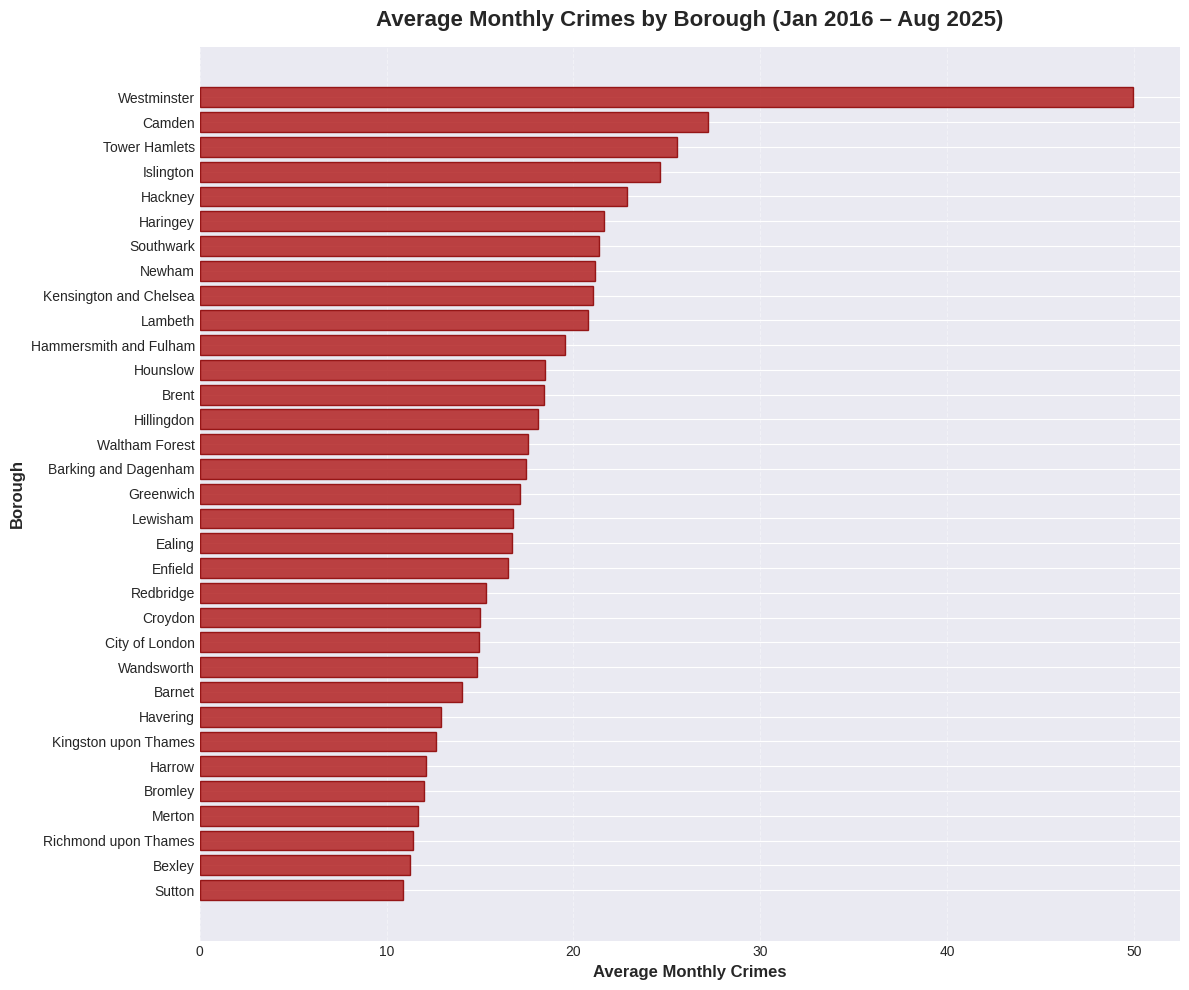

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

# Compute mean monthly crime per borough
borough_crimes = df.groupby('Borough')['Total Crimes'].mean().sort_values(ascending=True)

plt.figure(figsize=(12, 10))

bars = plt.barh(
    borough_crimes.index,
    borough_crimes.values,
    color='firebrick',
    alpha=0.85,
    edgecolor='darkred'
)

plt.title('Average Monthly Crimes by Borough (Jan 2016 – Aug 2025)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Average Monthly Crimes', fontsize=12, fontweight='bold')
plt.ylabel('Borough', fontsize=12, fontweight='bold')

plt.gca().xaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure proper font embedding for EPS
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "serif"

# Compute mean monthly crime per borough
borough_crimes = df.groupby('Borough')['Total Crimes'].mean().sort_values(ascending=True)

# Springer single-column width ≈ 8–9 cm → ~3.5 inches
plt.figure(figsize=(3.5, 4.5))

plt.barh(
    borough_crimes.index,
    borough_crimes.values,
    edgecolor='black'
)

plt.xlabel('Average Monthly Crimes', fontsize=9)
plt.ylabel('Borough', fontsize=9)
plt.title('Average Monthly Crimes by Borough (2016–2025)', fontsize=10)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()

# Save as EPS (vector format)
plt.savefig("AverageMonthlyCrimes_Borough.eps",
            format="eps",
            bbox_inches="tight")

plt.close()

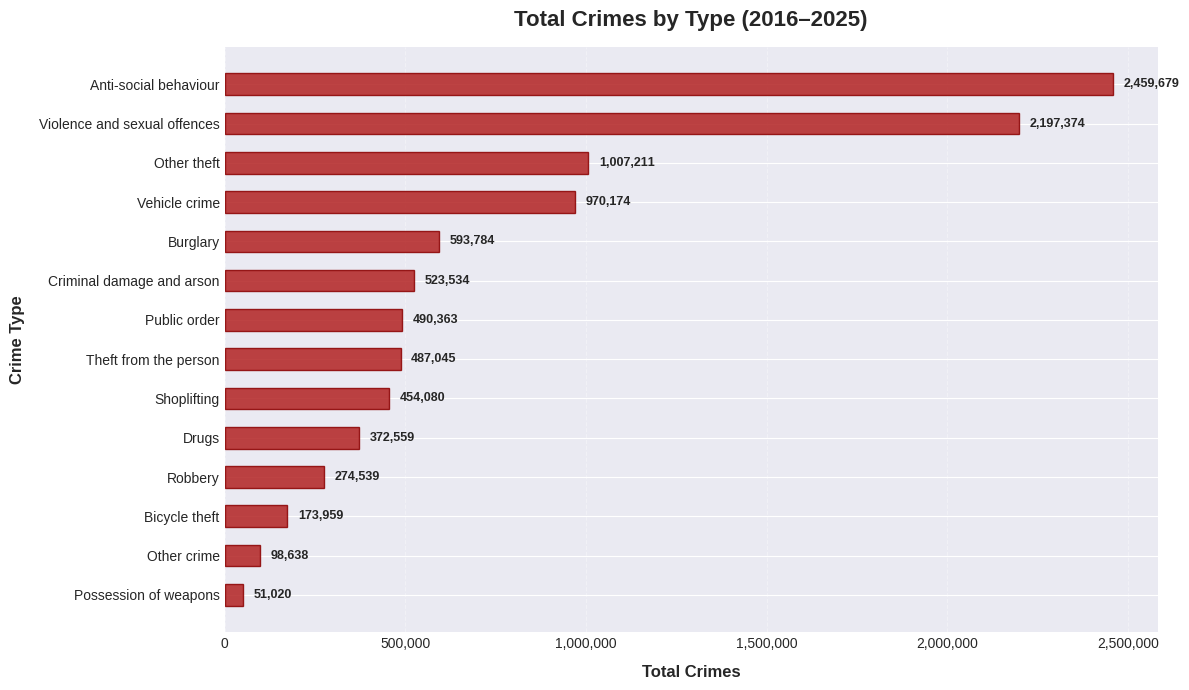

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

crime_columns = [
    'Anti-social behaviour', 'Bicycle theft', 'Burglary',
    'Criminal damage and arson', 'Drugs', 'Other crime',
    'Other theft', 'Possession of weapons', 'Public order',
    'Robbery', 'Shoplifting', 'Theft from the person',
    'Vehicle crime', 'Violence and sexual offences'
]

plt.style.use('seaborn-v0_8-darkgrid')

crime_totals = df[crime_columns].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 7))

bar_height = 0.55
indices = np.arange(len(crime_totals))

bars = plt.barh(indices, crime_totals.values,
                height=bar_height,
                color='firebrick', alpha=0.85, edgecolor='darkred')

plt.title('Total Crimes by Type (2016–2025)',
          fontsize=16, fontweight='bold', pad=15)

plt.xlabel('Total Crimes', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Crime Type', fontsize=12, fontweight='bold', labelpad=10)

plt.yticks(indices, crime_totals.index, fontsize=10)

# Format X-axis with commas
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.grid(True, axis='x', linestyle='--', alpha=0.35)

# Add value labels at end of bars
for bar, value in zip(bars, crime_totals.values):
    plt.text(value + crime_totals.max() * 0.012,      # small offset
             bar.get_y() + bar.get_height() / 2,
             f'{value:,.0f}',
             va='center', ha='left',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

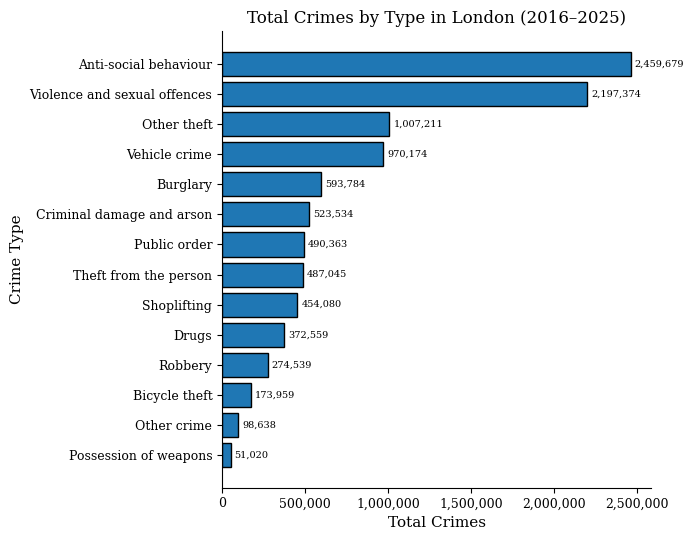

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# Proper font embedding for EPS
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "serif"

crime_totals = df[crime_columns].sum().sort_values(ascending=True)

plt.figure(figsize=(7, 5.5))

indices = np.arange(len(crime_totals))

ax = plt.gca()

bars = ax.barh(indices, crime_totals.values,
               edgecolor='black')

ax.set_title('Total Crimes by Type in London (2016–2025)', fontsize=12)
ax.set_xlabel('Total Crimes', fontsize=11)
ax.set_ylabel('Crime Type', fontsize=11)

ax.set_yticks(indices)
ax.set_yticklabels(crime_totals.index, fontsize=9)
ax.tick_params(axis='x', labelsize=9)

# Format x-axis with commas
ax.xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

# ---- Remove top and right borders ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, value in enumerate(crime_totals.values):
    plt.text(value + max_value * 0.01,  # small offset
             i,
             f'{value:,.0f}',
             va='center',
             fontsize=7)


plt.tight_layout()

plt.savefig("TotalCrimes_ByType.eps",
            format="eps",
            bbox_inches="tight")

plt.show()
plt.close()

NameError: name 'ax' is not defined

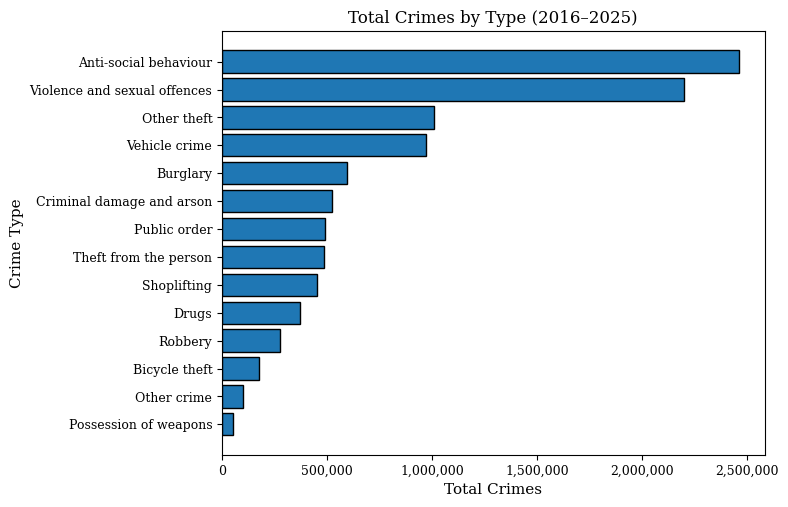

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "serif"

crime_totals = df[crime_columns].sum().sort_values(ascending=True)

# ---- Two-column Springer size ----
plt.figure(figsize=(7, 5.5))   # wider + taller for 14 categories

indices = np.arange(len(crime_totals))

bars = plt.barh(indices, crime_totals.values,
                edgecolor='black')

plt.title('Total Crimes by Type (2016–2025)', fontsize=12)
plt.xlabel('Total Crimes', fontsize=11)
plt.ylabel('Crime Type', fontsize=11)

plt.yticks(indices, crime_totals.index, fontsize=9)
plt.xticks(fontsize=9)

# Format x-axis with commas
plt.gca().xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
max_value = crime_totals.max()

for i, value in enumerate(crime_totals.values):
    plt.text(value + max_value * 0.01,  # small offset
             i,
             f'{value:,.0f}',
             va='center',
             fontsize=7)


plt.tight_layout()

# ---- Export as EPS ----
plt.savefig("TotalCrimes_ByType.eps",
            format="eps",
            bbox_inches="tight")

plt.show()   # Keep this so you can preview
plt.close()

In [ ]:
stat_summary = df[crime_columns].agg(['min', 'max', 'mean', 'median', 'std']).T

# Rename index & columns for clean presentation
stat_summary.index.name = "CrimeType"
stat_summary.reset_index(inplace=True)
stat_summary.columns = ["CrimeType", "Min", "Max", "Mean", "Median", "Std"]

# Display table
stat_summary.head(15)

,CrimeType,Min,Max,Mean,Median,Std
0,Anti-social behaviour,0.0,164.0,4.385549,3.0,5.781074
1,Bicycle theft,0.0,56.0,0.310165,0.0,0.924686
2,Burglary,0.0,52.0,1.058703,1.0,1.456070
3,Criminal damage and arson,0.0,36.0,0.933449,1.0,1.316549
4,Drugs,0.0,82.0,0.664264,0.0,1.591790
5,Other crime,0.0,171.0,0.175869,0.0,1.375070
6,Other theft,0.0,517.0,1.795833,1.0,6.203140
7,Possession of weapons,0.0,15.0,0.090967,0.0,0.351443
8,Public order,0.0,62.0,0.874306,0.0,1.550313
9,Robbery,0.0,83.0,0.489496,0.0,1.384013


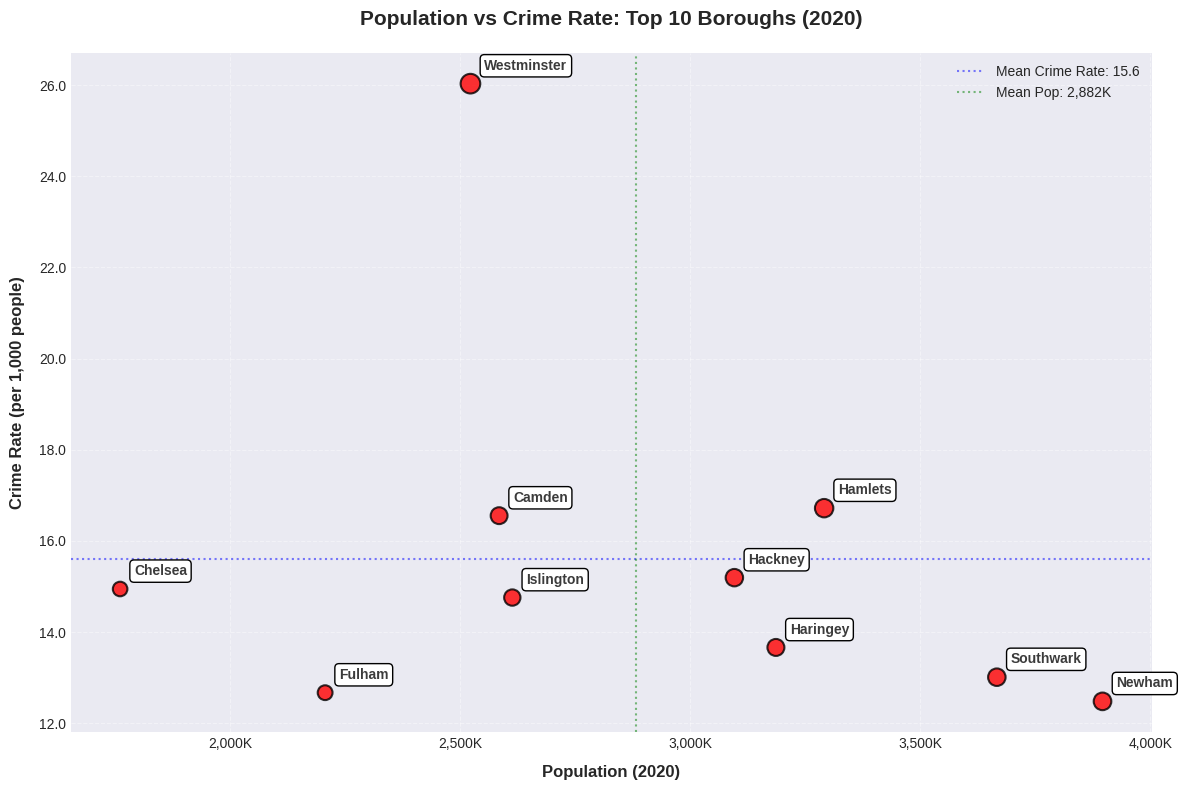

In [ ]:
yearly_crimes = df.groupby('Year')['Total Crimes'].sum()
max_crime_year = yearly_crimes.idxmax()
max_crime_data = df[df['Year'] == max_crime_year]

borough_stats = max_crime_data.groupby('Borough').agg({
    'Population': 'sum',
    'Total Crimes': 'sum'
})

borough_stats['Crime Rate per 1k'] = (borough_stats['Total Crimes'] / borough_stats['Population']) * 1000
borough_stats = borough_stats.sort_values('Crime Rate per 1k', ascending=False).head(10)

plt.figure(figsize=(12, 8))

sizes = 50 + (borough_stats['Total Crimes'] / borough_stats['Total Crimes'].max() * 150)

plt.scatter(borough_stats['Population'],
            borough_stats['Crime Rate per 1k'],
            c='red',
            alpha=0.8,
            s=sizes,  # Dynamic sizing
            edgecolor='black',
            linewidth=1.5,
            zorder=5)

plt.xlabel(f'Population ({max_crime_year})', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Crime Rate (per 1,000 people)', fontsize=12, fontweight='bold', labelpad=10)
plt.title(f'Population vs Crime Rate: Top 10 Boroughs ({max_crime_year})',
          fontsize=15, fontweight='bold', pad=20)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:,.0f}K'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))

for i, borough in enumerate(borough_stats.index):
    plt.annotate(borough.split()[-1] if len(borough.split()) > 1 else borough[:15],
                 (borough_stats['Population'].iloc[i], borough_stats['Crime Rate per 1k'].iloc[i]),
                 xytext=(10, 10),
                 textcoords='offset points',
                 fontsize=10,
                 fontweight='bold',
                 alpha=0.9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=1, edgecolor='black'))

plt.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)

plt.axhline(y=borough_stats['Crime Rate per 1k'].mean(),
            color='blue',
            linestyle=':',
            alpha=0.5,
            linewidth=1.5,
            label=f'Mean Crime Rate: {borough_stats["Crime Rate per 1k"].mean():.1f}')

plt.axvline(x=borough_stats['Population'].mean(),
            color='green',
            linestyle=':',
            alpha=0.5,
            linewidth=1.5,
            label=f'Mean Pop: {borough_stats["Population"].mean()/1000:,.0f}K')

plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

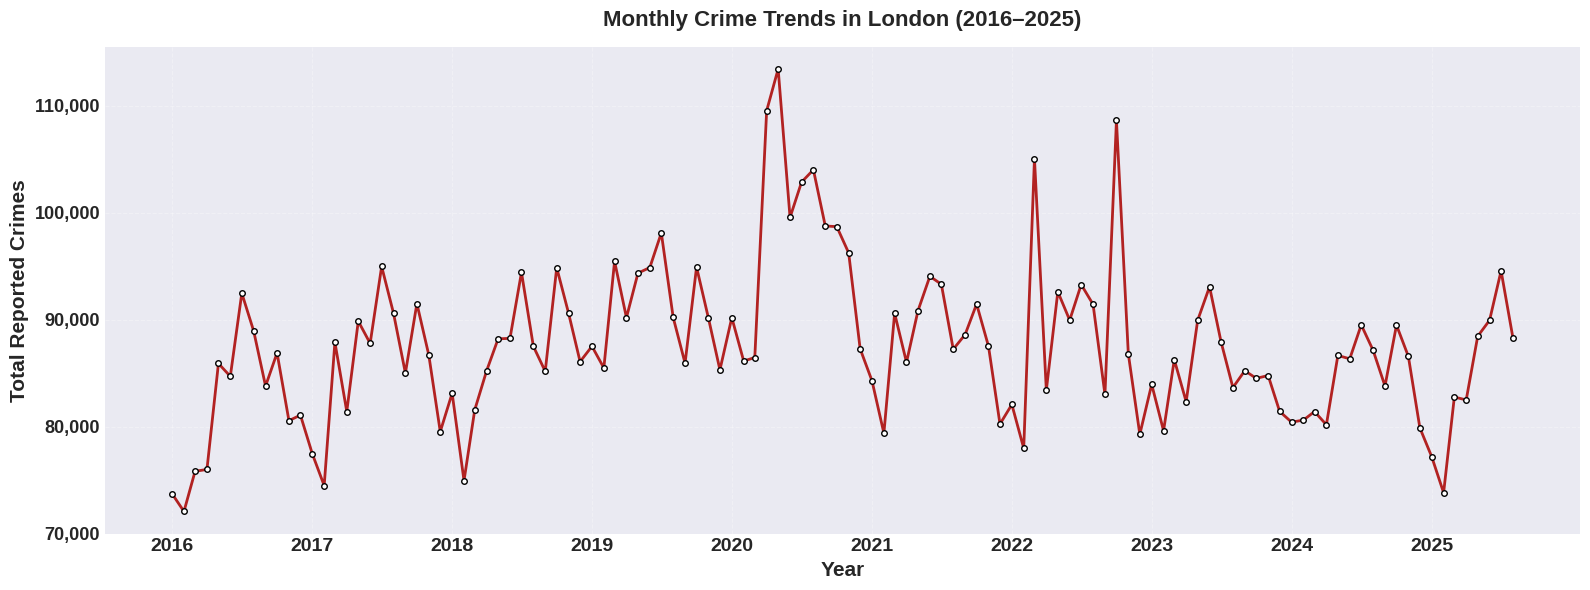

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Ensure datetime format
df['Month'] = pd.to_datetime(df['Month'])

# Aggregate monthly crime totals
monthly_crimes = df.groupby('Month')['Total Crimes'].sum()

plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(16, 6))

# Line + circle markers on each month
plt.plot(monthly_crimes.index,
         monthly_crimes.values,
         linewidth=2,
         marker='o', markersize=4,
         markeredgecolor='black', markerfacecolor='white',
         color='firebrick')

plt.title("Monthly Crime Trends in London (2016–2025)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=15, fontweight='bold')
plt.ylabel("Total Reported Crimes", fontsize=15, fontweight='bold')

years = monthly_crimes.index.year
unique_years = sorted(set(years))

year_positions = [monthly_crimes.index[years == y][0] for y in unique_years]
plt.xticks(year_positions, unique_years, rotation=0, fontsize=14, fontweight='bold')

# Format y-axis + make bold
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.yticks(fontsize=13, fontweight='bold')   # <-- **Bold y-axis numbers**

plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


# 1.7 Correlation Check

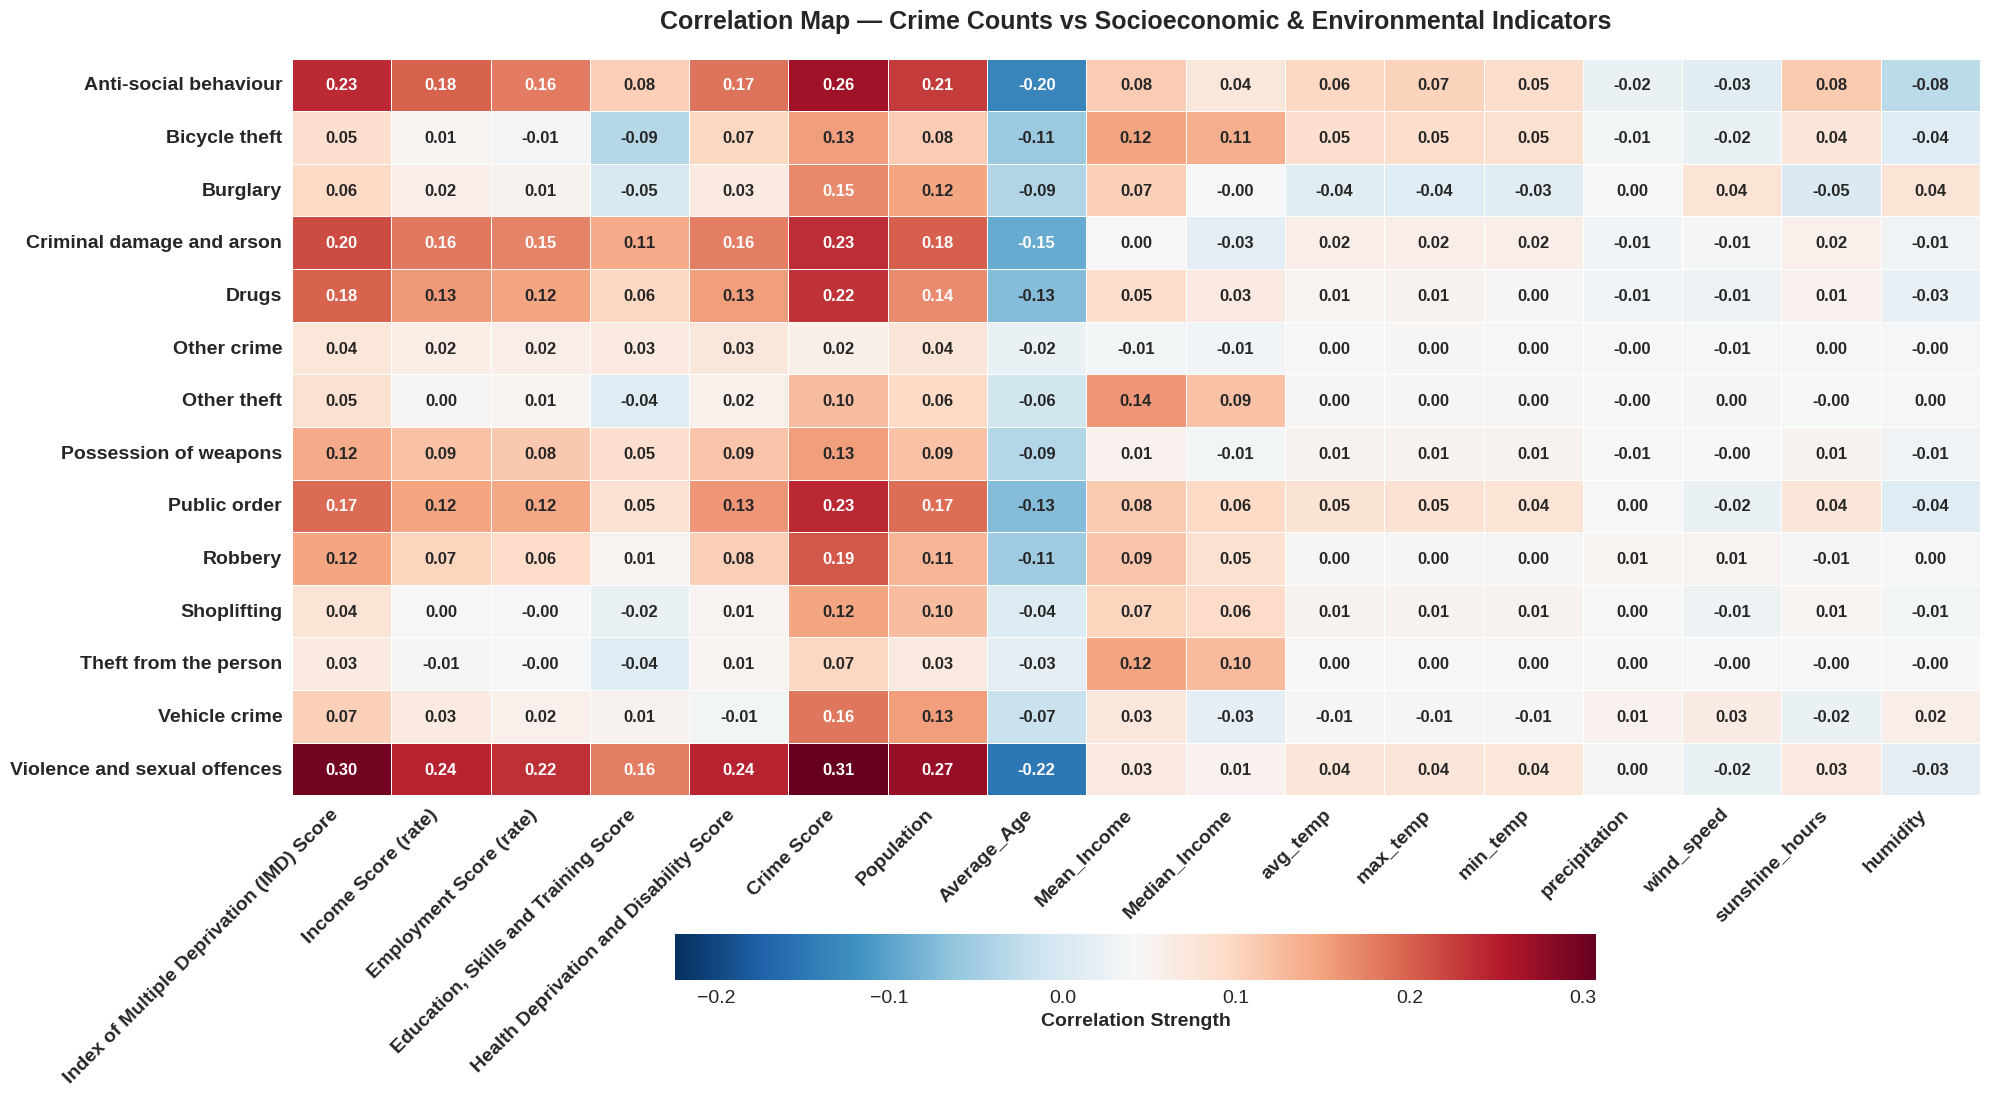

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

crime_features = [
    'Anti-social behaviour', 'Bicycle theft', 'Burglary',
    'Criminal damage and arson', 'Drugs', 'Other crime',
    'Other theft', 'Possession of weapons', 'Public order',
    'Robbery', 'Shoplifting', 'Theft from the person',
    'Vehicle crime', 'Violence and sexual offences'
]

other_features = [
    'Index of Multiple Deprivation (IMD) Score',
    'Income Score (rate)', 'Employment Score (rate)',
    'Education, Skills and Training Score',
    'Health Deprivation and Disability Score', 'Crime Score',
    'Population', 'Average_Age', 'Mean_Income', 'Median_Income',
    'avg_temp', 'max_temp', 'min_temp', 'precipitation', 'wind_speed', 'sunshine_hours', 'humidity'
]

focus_data = df[crime_features + other_features]
corr_matrix = focus_data.corr()
crime_vs_other = corr_matrix.loc[crime_features, other_features]

plt.figure(figsize=(20, 12))

ax = sns.heatmap(
    crime_vs_other,
    cmap='RdBu_r',
    center=0,
    square=False,
    annot=True,
    fmt='.2f',
    linewidths=0.7,
    annot_kws={'size': 12, 'fontweight': 'bold'},  # Bigger numbers
    cbar=False  # We will add a separate colorbar
)

plt.title(
    'Correlation Map — Crime Counts vs Socioeconomic & Environmental Indicators',
    fontsize=18, fontweight='bold', pad=22
)

plt.subplots_adjust(bottom=0.5)
norm = plt.Normalize(vmin=crime_vs_other.min().min(),
                     vmax=crime_vs_other.max().max())
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
sm.set_array([])

cbar = plt.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    pad=0.15,
    fraction=0.05
)
cbar.set_label("Correlation Strength", fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=14)

# Axis tick style updates
plt.xticks(rotation=45, ha='right', fontsize=14, fontweight='semibold')
plt.yticks(fontsize=14, fontweight='semibold')

plt.tight_layout()
plt.show()

# 2. Data Preprocessing
##2.1 Feature Engineering

In [ ]:
import pandas as pd
csv_data = pd.read_csv("/content/drive/MyDrive/lsoa_crime_imd_pop_income_weather.csv")

csv_data['crime_density'] = csv_data['Total Crimes'] / csv_data['Population'].clip(lower=1)
csv_data['taxpayer_ratio'] = csv_data['Num_Taxpayers'] / csv_data['Population'].clip(lower=1)
csv_data['borough_mean_crime'] = csv_data.groupby(['Borough','Month'])['Total Crimes'].transform('mean')

In [ ]:
csv_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560860 entries, 0 to 560859
Data columns (total 43 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   LSOA code                                  560860 non-null  object 
 1   Month                                      560860 non-null  object 
 2   LSOA name                                  560860 non-null  object 
 3   Anti-social behaviour                      560860 non-null  float64
 4   Bicycle theft                              560860 non-null  float64
 5   Burglary                                   560860 non-null  float64
 6   Criminal damage and arson                  560860 non-null  float64
 7   Drugs                                      560860 non-null  float64
 8   Other crime                                560860 non-null  float64
 9   Other theft                                560860 non-null  float64
 10  Possessi

# 2.2 Lag Features

In [ ]:
csv_data = csv_data.sort_values(['LSOA code', 'Month'])

crime_columns = [
    'Anti-social behaviour', 'Bicycle theft', 'Burglary',
    'Criminal damage and arson', 'Drugs', 'Other crime',
    'Other theft', 'Possession of weapons', 'Public order',
    'Robbery', 'Shoplifting', 'Theft from the person',
    'Vehicle crime', 'Violence and sexual offences'
]

lags = [1, 2, 3, 6, 12]

# Create all lagged columns in a list first, then concat
lagged_data = []
for lag in lags:
    for crime_col in crime_columns:
        lagged_series = csv_data.groupby('LSOA code')[crime_col].shift(lag)
        lagged_series.name = f'{crime_col}_lag_{lag}'
        lagged_data.append(lagged_series)

lagged_df = pd.concat(lagged_data, axis=1)
csv_data = pd.concat([csv_data, lagged_df], axis=1)

print(f"Created {len(lags) * len(crime_columns)} lagged features")

Created 70 lagged features


# 2.2 Creating Rolling or Window Features to Capture Trends

**Rolling features are performed to capture temporal patterns and trends that individual data points miss.**

While lagged features show what happened at specific past time points, rolling features analyze the **shape and behavior** of the data over time windows. They reveal:

- **Trends and directions** (is crime increasing/decreasing over recent months?)
- **Stability and volatility** (is crime becoming more unpredictable?)
- **Seasonal patterns** (weekly, monthly, or quarterly cycles)
- **Data smoothing** (removing random noise to see underlying patterns)
- **Contextual behavior** (how current values compare to recent history)

Rolling statistics transform point-in-time data into **behavioral patterns**, helping models understand not just what happened, but **how it's happening** over time. This is crucial for predicting complex temporal phenomena like crime patterns that evolve gradually rather than changing abruptly.

In [ ]:
csv_data = csv_data.sort_values(["LSOA code", "Month"])

windows = [3, 6]
rolling_features = []

for crime_col in crime_columns:
    for window in windows:
        roll = csv_data.groupby("LSOA code")[crime_col].rolling(window).agg(['mean', 'std', 'min', 'max', 'sum'])
        roll = roll.reset_index(level=0, drop=True)  # remove group offset

        rolling_features.append(roll['mean'].rename(f'{crime_col}_rolling_mean_{window}'))
        rolling_features.append(roll['std'].rename(f'{crime_col}_rolling_std_{window}'))
        rolling_features.append(roll['min'].rename(f'{crime_col}_rolling_min_{window}'))
        rolling_features.append(roll['max'].rename(f'{crime_col}_rolling_max_{window}'))
        rolling_features.append(roll['sum'].rename(f'{crime_col}_rolling_sum_{window}'))

rolling_df = pd.concat(rolling_features, axis=1)
csv_data = pd.concat([csv_data, rolling_df], axis=1)

print(f"Created {len(windows) * len(crime_columns) * 5} rolling features")

Created 140 rolling features


# 2.3 Cyclical Encoding

**Cyclical encoding is performed because time features like months, days and hours are cyclical in nature not linear**

In normal,
- Regular encoding treats month 12 (December) as far from month 1 (January)
- But in reality, December and January are adjacent months
- This creates artificial distance that misleads machine learning models

Cyclical encoding uses sine and cosine transformations to represent time features as points on a circle, so:
- December becomes close to January
- 23:00 becomes close to 00:00  
- Sunday becomes close to Monday

Therefore, Models understand the true cyclical relationships in time data, leading to better predictions for seasonal patterns like crime trends.

In [ ]:
import numpy as np

csv_data['Month_dt'] = pd.to_datetime(csv_data['Month'])
csv_data['month_sin'] = np.sin(2 * np.pi * csv_data['Month_dt'].dt.month / 12)
csv_data['month_cos'] = np.cos(2 * np.pi * csv_data['Month_dt'].dt.month / 12)

print("Created cyclical month encoding:")
print(f"   January: sin={np.sin(2*np.pi*1/12):.3f}, cos={np.cos(2*np.pi*1/12):.3f}")
print(f"   December: sin={np.sin(2*np.pi*12/12):.3f}, cos={np.cos(2*np.pi*12/12):.3f}")

csv_data = csv_data.drop(columns=['Month_dt'])

Created cyclical month encoding:
   January: sin=0.500, cos=0.866
   December: sin=-0.000, cos=1.000


# 2.4 Handling Missing Data

In [ ]:
print(csv_data.isna().sum().sort_values(ascending=False).head(5))
print("\nShape", csv_data.shape)

Robbery_lag_12                      58020
Criminal damage and arson_lag_12    58020
Burglary_lag_12                     58020
Possession of weapons_lag_12        58020
Other theft_lag_12                  58020
dtype: int64

Shape (560860, 255)


In [ ]:
csv_data.dropna(inplace=True)
csv_data.reset_index(drop=True, inplace=True)
print("Shape", csv_data.shape)

Shape (502840, 255)


In [ ]:
csv_data['Month']

,Month
0,2017-01
1,2017-02
2,2017-03
3,2017-04
4,2017-05
...,...
502835,2025-04
502836,2025-05
502837,2025-06
502838,2025-07


In [ ]:
lagged_cols = [col for col in csv_data.columns if 'lag_' in col]
rolling_cols = [col for col in csv_data.columns if 'rolling_' in col]

print("FEATURE CREATION CHECK:")
print(f"Original columns: {len([col for col in csv_data.columns if 'lag_' not in col and 'rolling_' not in col])}")
print(f"Expected lagged features: {14 * 5} = {len(lagged_cols)} created")
print(f"Expected rolling features: {14 * 2 * 5} = {len(rolling_cols)} created")
print(f"Total features: {len(csv_data.columns)}")

FEATURE CREATION CHECK:
Original columns: 45
Expected lagged features: 70 = 70 created
Expected rolling features: 140 = 140 created
Total features: 255


# 2.5 Node ID mapping for GNN Model
GNNs require numeric node IDs such as 0, 1, 2 for each LSOA to become a node in the graph.

In [ ]:
csv_data = csv_data.sort_values(["LSOA code", "Month"]).reset_index(drop=True)

unique_lsoas = sorted(csv_data["LSOA code"].unique())

# Map each LSOA to an index
lsoa_to_idx = {code: i for i, code in enumerate(unique_lsoas)}
csv_data["node_id"] = csv_data["LSOA code"].map(lsoa_to_idx)

print("node_id column created:")
print(csv_data[["LSOA code", "node_id"]].nunique)

node_id column created:
<bound method DataFrame.nunique of         LSOA code  node_id
0       E01000001        0
1       E01000001        0
2       E01000001        0
3       E01000001        0
4       E01000001        0
...           ...      ...
502835  E01033746     4834
502836  E01033746     4834
502837  E01033746     4834
502838  E01033746     4834
502839  E01033746     4834

[502840 rows x 2 columns]>


In [ ]:
csv_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502840 entries, 0 to 502839
Columns: 256 entries, LSOA code to node_id
dtypes: float64(250), int64(2), object(4)
memory usage: 982.1+ MB


In [ ]:
output_path = "/content/drive/MyDrive/clean_data/crime_data.csv"

csv_data.to_csv(output_path, index=False)

print(f"File saved successfully to: {output_path}")

File saved successfully to: /content/drive/MyDrive/clean_data/crime_data.csv


In [ ]:
import pandas as pd
csv_data = pd.read_csv("/content/drive/MyDrive/clean_data/crime_data.csv")

In [ ]:
print("Unique LSOA codes:", csv_data["LSOA code"].nunique())
print("Unique node IDs:", csv_data["node_id"].nunique())

Unique LSOA codes: 4835
Unique node IDs: 4835


# **2.6 Adjancency Matrix**

Firstly, the shapefiles are extracted from the ZIP package as the ZIP contains several supporting files (such as .shp, .shx, .dbf) required by a shapefile.

In [ ]:
import geopandas as gpd
import glob
import zipfile
import os
import pandas as pd

zip_path = "/content/drive/MyDrive/LSOA_BFE_London.zip" # Extract Shapefile Zip
extract_path = "/content/temp_lsoa"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("London LSOA shapefiles extracted.")

shp_files = glob.glob(f"{extract_path}/LSOA_2011_BFE_London/*.shp") # Extract Shapefile Zip
print(f"Found {len(shp_files)} shapefiles.")

sample = gpd.read_file(shp_files[0])
lsoa_col = next((c for c in sample.columns if "LSOA" in c.upper()), None)
print(f"Detected LSOA Code Column Name in Shp File: {lsoa_col}")

all_lsoas = set()
for shp in shp_files:
    gdf = gpd.read_file(shp)
    all_lsoas.update(gdf[lsoa_col])

print(f"Total Unique LSOAs in London Shp File: {len(all_lsoas)}")

London LSOA shapefiles extracted.
Found 33 shapefiles.
Detected LSOA Code Column Name in Shp File: LSOA11CD
Total Unique LSOAs in London Shp File: 4835


Then, Consistency Check is performed between Crime LSOAs vs Shapefile LSOAs

In [ ]:
gdf = gpd.GeoDataFrame()
for shp_file in shp_files:
    borough_gdf = gpd.read_file(shp_file)
    gdf = pd.concat([gdf, borough_gdf], ignore_index=True)

csv_codes = set(csv_data['LSOA code'].unique())
shp_codes = set(gdf['LSOA11CD'].unique())

common = csv_codes.intersection(shp_codes)
match_pct = (len(common) / len(csv_codes)) * 100

print("CONSISTENCY CHECK:")
print(f"CSV LSOAs: {len(csv_codes)}")
print(f"SHP LSOAs: {len(shp_codes)}")
print(f"Common: {len(common)}")
print(f"Match: {match_pct:.1f}%")

CONSISTENCY CHECK:
CSV LSOAs: 4835
SHP LSOAs: 4835
Common: 4835
Match: 100.0%


Examine what are included in each shp files

In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 4835 entries, 0 to 4834
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   LSOA11CD   4835 non-null   object  
 1   LSOA11NM   4835 non-null   object  
 2   MSOA11CD   4835 non-null   object  
 3   MSOA11NM   4835 non-null   object  
 4   LAD11CD    4835 non-null   object  
 5   LAD11NM    4835 non-null   object  
 6   RGN11CD    4835 non-null   object  
 7   RGN11NM    4835 non-null   object  
 8   USUALRES   4835 non-null   int32   
 9   HHOLDRES   4835 non-null   int32   
 10  COMESTRES  4835 non-null   int32   
 11  POPDEN     4835 non-null   float64 
 12  HHOLDS     4835 non-null   int32   
 13  AVHHOLDSZ  4835 non-null   float64 
 14  geometry   4835 non-null   geometry
dtypes: float64(2), geometry(1), int32(4), object(8)
memory usage: 491.2+ KB


In [ ]:
print("GEOMETRY COLUMN INFO:")
print(f"Data type: {type(gdf.geometry)}")
print(f"First geometry type: {gdf.geometry.iloc[0].geom_type}")
print(f"Total geometries: {len(gdf.geometry)}")

print(f"\nSAMPLE GEOMETRY:")
print(gdf.geometry.iloc[0])

GEOMETRY COLUMN INFO:
Data type: <class 'geopandas.geoseries.GeoSeries'>
First geometry type: Polygon
Total geometries: 4835

SAMPLE GEOMETRY:
POLYGON ((531004.114 179649.142, 531000.143 179644.179, 531000 179644, 530995.518 179638.771, 530994.969 179638.131, 530994 179637, 530992 179637, 530991.883 179637.022, 530982.253 179638.805, 530962.437 179642.475, 530949.542 179644.863, 530956.212 179637.978, 530957.007 179637.157, 530960.872 179633.169, 530975.194 179618.388, 530978.152 179567.137, 530978.204 179566.238, 530981 179564, 530983 179563, 530986.852 179560.055, 530987.208 179560.46, 531011.102 179587.647, 531021.205 179590.095, 531023.257 179590.593, 531031.427 179585.842, 531034.045 179584.32, 531037.407 179582.364, 531039.546 179581.514, 531044.042 179579.729, 531057.222 179575.725, 531062.071 179568.942, 531088.705 179561.324, 531089.328 179561.147, 531089.503 179558.651, 531090.543 179543.841, 531095.186 179542.912, 531104.928 179557.524, 531108.914 179555.312, 531112.536 1795

In [ ]:
if "LSOA11CD" in gdf.columns:
    gdf = gdf.rename(columns={"LSOA11CD": "LSOA code"})

In [ ]:
unique_lsoas = sorted(csv_data["LSOA code"].unique())
lsoa_to_idx = {code: i for i, code in enumerate(unique_lsoas)}

gdf = gdf[gdf["LSOA code"].isin(unique_lsoas)].copy()
gdf = gdf.sort_values("LSOA code").reset_index(drop=True)

gdf["node_id"] = gdf["LSOA code"].map(lsoa_to_idx)

gdf = gdf.sort_values("node_id").reset_index(drop=True)

In [ ]:
gdf.head()

,LSOA code,LSOA11NM,MSOA11CD,MSOA11NM,LAD11CD,LAD11NM,RGN11CD,RGN11NM,USUALRES,HHOLDRES,COMESTRES,POPDEN,HHOLDS,AVHHOLDSZ,geometry,node_id
0,E01000001,City of London 001A,E02000001,City of London 001,E09000001,City of London,E12000007,London,1465,1465,0,112.9,876,1.7,"POLYGON ((532151.55 181867.395, 532152.5 18186...",0
1,E01000002,City of London 001B,E02000001,City of London 001,E09000001,City of London,E12000007,London,1436,1436,0,62.9,830,1.7,"POLYGON ((532634.494 181926.001, 532632.048 18...",1
2,E01000003,City of London 001C,E02000001,City of London 001,E09000001,City of London,E12000007,London,1346,1250,96,227.7,817,1.5,"POLYGON ((532153.703 182165.155, 532158.25 182...",2
3,E01000005,City of London 001E,E02000001,City of London 001,E09000001,City of London,E12000007,London,985,985,0,52.0,467,2.1,"POLYGON ((533619.062 181402.364, 533639.868 18...",3
4,E01000006,Barking and Dagenham 016A,E02000017,Barking and Dagenham 016,E09000002,Barking and Dagenham,E12000007,London,1703,1699,4,116.2,543,3.1,"POLYGON ((545126.852 184310.838, 545145.213 18...",4


In [ ]:
print("Unique LSOA codes:", gdf["LSOA code"].nunique())
print("Unique node IDs:", gdf["node_id"].nunique())

csv_lsoas = set(csv_data["LSOA code"].unique())
gdf_lsoas  = set(gdf["LSOA code"].unique())

print("Are all LSOA codes identical?", csv_lsoas == gdf_lsoas)

Unique LSOA codes: 4835
Unique node IDs: 4835
Are all LSOA codes identical? True


# 2.6.1 KNN

To capture spatial relationships based on geographical proximity, we also constructed a K-Nearest Neighbour (KNN) adjacency matrix. For every LSOA, the Euclidean distance to all other LSOAs are calculated, the 8 closest areas are assumed as neighbours and a connection (edge) is assigned between them.

For richer spatial dependencies, both of them are used as multi-support setting to help the STGNN capture.

In [ ]:
import numpy as np
from sklearn.neighbors import kneighbors_graph

# Extract centroid coordinates for each LSOA
coords = np.array([(geom.centroid.x, geom.centroid.y) for geom in gdf.geometry])

# KNN graph using Euclidean distances
A_knn_dist = kneighbors_graph(
    coords,
    n_neighbors=8,
    mode='distance',
    include_self=False
)

A_knn = A_knn_dist.toarray().astype(np.float32) # Convert sparse matrix

eps = 1e-6
nonzero_mask = A_knn > 0 # Convert distances to inverse-distance weights # w_ij = 1 / (d_ij + ε)
A_knn[nonzero_mask] = 1.0 / (A_knn[nonzero_mask] + eps)

row_sums = A_knn.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
A_knn = A_knn / row_sums

np.save("/content/drive/MyDrive/A_knn.npy", A_knn)

print("Weighted KNN adjacency saved at /content/drive/MyDrive/A_knn.npy")

Weighted KNN adjacency saved at /content/drive/MyDrive/A_knn.npy


# 2.7 Train-Test Split & Scaling & Cross-Validation

In [ ]:
import pandas as pd
csv_data = pd.read_csv("/content/drive/MyDrive/clean_data/crime_data.csv")

In [ ]:
drop_cols = ['Borough', 'Year', 'Total Crimes']
csv_data = csv_data.drop(columns=[c for c in drop_cols if c in csv_data.columns])

In [ ]:
csv_data.shape #After Dropping Columns

(502840, 253)

In [ ]:
import pandas as pd
import numpy as np

def check_feature_distribution(df):
    results = []

    for col in df.columns:
        series = df[col].dropna()

        # Skip non-numeric columns
        if not pd.api.types.is_numeric_dtype(series):
            results.append([col, "N/A", "N/A"])
            continue

        # Skewness
        skew = series.skew()

        # Outlier ratio (IQR)
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        outlier_ratio = ((series < lower) | (series > upper)).mean()

        results.append([col, skew, outlier_ratio])

    return pd.DataFrame(results, columns=["Feature", "Skewness", "Outlier_Ratio"])

dist_info = check_feature_distribution(csv_data)
dist_info

,Feature,Skewness,Outlier_Ratio
0,LSOA code,N/A,N/A
1,Month,N/A,N/A
2,LSOA name,N/A,N/A
3,Anti-social behaviour,4.482147,0.057434
4,Bicycle theft,8.498241,0.18666
...,...,...,...
248,Violence and sexual offences_rolling_max_6,5.101966,0.0384
249,Violence and sexual offences_rolling_sum_6,6.923871,0.051281
250,month_sin,-0.048269,0.0
251,month_cos,0.048269,0.0


In [ ]:
def recommend_scaling(df):
    dist_info = check_feature_distribution(df)
    recs = []

    for _, row in dist_info.iterrows():
        col = row["Feature"]
        skew = row["Skewness"]
        outliers = row["Outlier_Ratio"]

        if skew == "N/A":
            rec = "No scaling (Non-numeric)"
            recs.append([col, rec])
            continue

        if pd.api.types.is_integer_dtype(df[col]) and df[col].min() >= 0 and df[col].max() > 1:
            rec = "No scaling (Count data for ZINB)"

        # Binary/low cardinality
        elif df[col].nunique() <= 10:
            rec = "No scaling (Binary/Categorical)"

        elif skew > 1 or outliers > 0.10:         # Heavy skew or many outliers → RobustScaler
            rec = "RobustScaler"

        else:
            rec = "StandardScaler"

        recs.append([col, rec])

    return pd.DataFrame(recs, columns=["Feature", "Recommended_Scaling"])

scaling_recommendations = recommend_scaling(csv_data)
scaling_recommendations

,Feature,Recommended_Scaling
0,LSOA code,No scaling (Non-numeric)
1,Month,No scaling (Non-numeric)
2,LSOA name,No scaling (Non-numeric)
3,Anti-social behaviour,RobustScaler
4,Bicycle theft,RobustScaler
...,...,...
248,Violence and sexual offences_rolling_max_6,RobustScaler
249,Violence and sexual offences_rolling_sum_6,RobustScaler
250,month_sin,StandardScaler
251,month_cos,StandardScaler


In [ ]:
lag_cols = [c for c in csv_data.columns if "_lag_" in c]
roll_cols = [c for c in csv_data.columns if "_rolling_" in c]

z_columns = [
    'Index of Multiple Deprivation (IMD) Score', 'Income Score (rate)',
    'Employment Score (rate)', 'Education, Skills and Training Score',
    'Health Deprivation and Disability Score', 'Crime Score',
    'Barriers to Housing and Services Score', 'Living Environment Score',
    'avg_temp', 'max_temp', 'min_temp', 'precipitation',
    'humidity', 'sunshine_hours', 'Average_Age', 'Population',
    'taxpayer_ratio', 'month_sin', 'month_cos', 'Num_Taxpayers',
    'Median_Income'
]

robust_columns = [
    'Mean_Income', 'wind_speed', 'crime_density', 'borough_mean_crime'
] + lag_cols + roll_cols

feature_cols = z_columns + robust_columns

crime_columns = [
    'Anti-social behaviour', 'Bicycle theft', 'Burglary', 'Criminal damage and arson',
    'Drugs', 'Other crime', 'Other theft', 'Possession of weapons',
    'Public order', 'Robbery', 'Shoplifting', 'Theft from the person',
    'Vehicle crime', 'Violence and sexual offences'
]

In [ ]:
len(feature_cols)

235

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.preprocessing import StandardScaler, RobustScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class STGNNCrimeDataset(Dataset):
    def __init__(self, df, feature_cols, crime_cols, seq_len=10, horizon=4):
        self.seq_len = seq_len
        self.horizon = horizon
        self.feature_cols = feature_cols # Added this line

        df = df.sort_values(["Month", "node_id"]).reset_index(drop=True)

        months = sorted(df["Month"].unique())
        nodes = sorted(df["node_id"].unique())

        T = len(months)
        N = len(nodes)
        F_dim = len(feature_cols)
        C_dim = len(crime_cols)

        X = np.zeros((T, N, F_dim), dtype=np.float32)
        Y = np.zeros((T, N, C_dim), dtype=np.float32)

        for i, col in enumerate(feature_cols):
            X[:, :, i] = df.pivot(index="Month", columns="node_id", values=col).values

        for j, col in enumerate(crime_cols):
            arr = df.pivot(index="Month", columns="node_id", values=col).values
            arr = np.clip(arr, 0, None)
            Y[:, :, j] = arr

        self.X = torch.tensor(X)
        self.Y = torch.tensor(Y)
        self.max_idx = T - seq_len - horizon + 1

    def __len__(self):
        return self.max_idx

    def __getitem__(self, idx):
        X_seq = self.X[idx:idx + self.seq_len]
        Y_seq = self.Y[idx + self.seq_len : idx + self.seq_len + self.horizon]
        return X_seq, Y_seq.permute(1, 0, 2)  # [N, H, C]

In [ ]:
SEQ_LEN = 12
HORIZON = 4
NEEDED_MONTHS = SEQ_LEN + HORIZON   # 16

VAL_SIZE_MONTHS  = NEEDED_MONTHS    # 16
TEST_SIZE_MONTHS = NEEDED_MONTHS    # 16

In [ ]:
def make_month_folds(month_list, val_size, min_train_months):

    M = len(month_list)
    folds = []

    start = min_train_months

    while True:
        val_start = start
        val_end = val_start + val_size

        if val_end > M:
            break

        train_months = month_list[:val_start]
        val_months   = month_list[val_start:val_end]

        folds.append((train_months, val_months))

        start += val_size

    return folds

In [ ]:
all_months = sorted(csv_data["Month"].unique())

test_months = all_months[-TEST_SIZE_MONTHS:]
train_val_months = all_months[:-TEST_SIZE_MONTHS]

train_val_df = csv_data[csv_data["Month"].isin(train_val_months)].copy()
test_df      = csv_data[csv_data["Month"].isin(test_months)].copy()

In [ ]:
print("Total months:", len(all_months))
print("Train+Val months:", len(train_val_months))
print("Test months:", len(test_months))

Total months: 104
Train+Val months: 88
Test months: 16


In [ ]:
folds = make_month_folds(
    month_list=train_val_months,
    val_size=VAL_SIZE_MONTHS,      # 16
    min_train_months=NEEDED_MONTHS # at least 16 months for training
)

print(f"Number of CV folds: {len(folds)}")
for i, (tr_m, va_m) in enumerate(folds, 1):
    print(f"Fold {i}: Train {len(tr_m)} months, Valid {len(va_m)} months")

Number of CV folds: 4
Fold 1: Train 16 months, Valid 16 months
Fold 2: Train 32 months, Valid 16 months
Fold 3: Train 48 months, Valid 16 months
Fold 4: Train 64 months, Valid 16 months


In [ ]:
knn_adj = np.load("/content/drive/MyDrive/A_knn.npy")

   # Negative Binomial Distribution Formula

In [ ]:
import torch
import torch.nn.functional as fn

def zinb_nll(y, pi, mu, r, eps=1e-8, reduction="mean"):
    """
    y = The actual number of crimes (e.g., 0, 5, 10)
    pi = The probability that there are zero crimes (0-1)
    mu = The average number of crimes predicted by the model mu > 0
    r = The dispersion parameter (indicating how spread out the crimes can be) r > 0

    if actual y = 0 and pi = 0.7 (Good) 70% but pi = 0.1 (Bad) 10%
    if actual y > 0 and mu = 1.8 (Good) but mu = 0.3 (Bad)
    Variance = μ + (μ² / r)
    """
    # Negative Binomial Distribution Formula
    # P(Y=y) = Γ(y+r) / (Γ(r) * Γ(y+1)) * (r/(r+μ))^r * (μ/(r+μ))^y
    log_nb = (
        torch.lgamma(y + r) - torch.lgamma(r) - torch.lgamma(y + 1.0)
        + r * (torch.log(r + eps) - torch.log(r + mu + eps))
        + y * (torch.log(mu + eps) - torch.log(r + mu + eps))
    )

    y_is_zero = (y == 0) # check actual is 0 or not
    log_pi = torch.log(pi + eps) # log(π) = Probablility of Zero Crime
    log_1m_pi = torch.log1p(-pi + eps)  # log(1-π) = Probablility of Non Zero Crime
    log_nb_y0 = r * (torch.log(r + eps) - torch.log(r + mu + eps))

    log_p_zero = torch.logsumexp(torch.stack([log_pi, log_1m_pi + log_nb_y0], dim=-1), dim=-1) # If y = 0 : P(Y=0) = π + (1-π) * P_NB(Y=0)
    log_p_pos  = log_1m_pi + log_nb # If y > 0 : P(Y=y) = (1-π) * P_NB(Y=y)

    log_prob = torch.where(y_is_zero, log_p_zero, log_p_pos)
    nll = -log_prob # Negative Log-Likelihood Conversion
    if reduction == "mean":
        return nll.mean()
    elif reduction == "sum":
        return nll.sum()
    else:
        return nll

# 3. STGNN-ZINB Model Development

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as fn
import numpy as np

class DiffusionGCNLayer(nn.Module):
    """
    Diffusion-style graph convolution on a single adjacency matrix A.
    """
    def __init__(self, in_dim, out_dim, K=2):
        super().__init__()
        self.K = K

        self.W_f = nn.Parameter(torch.randn(K, in_dim, out_dim) * 0.01)         # Learnable weights for forward and backward diffusion
        self.W_b = nn.Parameter(torch.randn(K, in_dim, out_dim) * 0.01)

    def forward(self, X, A, AT):
        """
        X : [B*T, N, F]
        A : [N, N] (row-normalised KNN adjacency)
        AT: [N, N] (transpose of A)
        """
        BT, N_nodes, F = X.shape
        out_dim = self.W_f.size(2)

        expected_N = A.shape[0]
        if N_nodes != expected_N:
            raise ValueError(f"Mismatched number of nodes: X has {N_nodes}, but A has {expected_N}. X.shape={X.shape}, A.shape={A.shape}")

        H = torch.zeros(BT, N_nodes, out_dim, device=X.device)

        N_int = int(N_nodes)
        A_k = torch.eye(N_int, device=X.device)
        AT_k = torch.eye(N_int, device=X.device)

        # Check shapes after initialization
        if A_k.shape != (N_int, N_int):
            raise ValueError(f"torch.eye produced unexpected shape for A_k: {A_k.shape} for N_int={N_int}")

        for k in range(self.K):
            AX  = torch.einsum("ij,bjf->bif", A_k, X)
            ATX = torch.einsum("ij,bjf->bif", AT_k, X)

            H += torch.einsum("bif,fo->bio", AX,  self.W_f[k])
            H += torch.einsum("bif,fo->bio", ATX, self.W_b[k])

            A_k  = A_k @ A
            AT_k = AT_k @ AT

        return torch.relu(H)

class ZINBHead(nn.Module):
    def __init__(self, hidden_dim, num_crimes, horizon):
        super().__init__()
        out_dim = horizon * num_crimes

        self.pi_head = nn.Linear(hidden_dim, out_dim)
        self.mu_head = nn.Linear(hidden_dim, out_dim)
        self.r_head  = nn.Linear(hidden_dim, out_dim)

        nn.init.zeros_(self.pi_head.bias)
        nn.init.zeros_(self.mu_head.bias)
        nn.init.zeros_(self.r_head.bias)

    def forward(self, h_last, B, N, H, C):
        pi_logits = self.pi_head(h_last)
        mu_raw    = self.mu_head(h_last)
        r_raw     = self.r_head(h_last)

        pi = torch.sigmoid(pi_logits)
        mu = fn.softplus(mu_raw) + 1e-6
        r  = fn.softplus(r_raw)  + 1e-6

        return (
            pi.view(B, N, H, C),
            mu.view(B, N, H, C),
            r.view(B, N, H, C)
        )

class DiffusionSTGNN_ZINB(nn.Module):
    def __init__(self,
                 num_nodes,
                 num_features,
                 num_crimes,
                 horizon,
                 knn_adj,
                 hidden_dim=96,
                 num_heads=4,
                 dropout=0.1,
                 diff_hops=2):
        super().__init__()

        self.N = num_nodes
        self.F = num_features
        self.C = num_crimes
        self.H = horizon
        self.hidden = hidden_dim

        A = torch.tensor(knn_adj, dtype=torch.float32)         # Store adjacency as tensors
        self.register_buffer("A", A)
        self.register_buffer("AT", A.t())

        # Spatial Diffusion Layers
        self.dgcn1 = DiffusionGCNLayer(self.F, hidden_dim, K=diff_hops)
        self.dgcn2 = DiffusionGCNLayer(hidden_dim, hidden_dim, K=diff_hops)

        self.ln1 = nn.LayerNorm(hidden_dim)
        self.ln2 = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

        self.temporal_attn = nn.MultiheadAttention(         # Temporal Attention
            embed_dim=hidden_dim,
            num_heads=num_heads,
            batch_first=True
        )
        self.attn_norm = nn.LayerNorm(hidden_dim)

        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, 4*hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4*hidden_dim, hidden_dim)
        )

        self.zinb_head = ZINBHead(hidden_dim, num_crimes, horizon)         # ZINB Output

    def forward(self, X):
        """
        X : [B, T_in, N, F]
        """
        B, T_in, N, F = X.shape

        X_flat = X.reshape(B*T_in, N, F)         # Spatial Diffusion

        h = self.dgcn1(X_flat, self.A, self.AT)
        h = self.dropout(self.ln1(h))

        h = self.dgcn2(h, self.A, self.AT)
        h = self.dropout(self.ln2(h))

        h = h.reshape(B, T_in, N, self.hidden)         # Restore sequence shape
        h = h.permute(0, 2, 1, 3).reshape(B*N, T_in, self.hidden)

        attn_out, _ = self.temporal_attn(h, h, h)         # Temporal Self-Attention
        h = self.attn_norm(h + self.dropout(attn_out))
        h = h + self.ffn(h)
        h_last = h[:, -1, :]

        # ZINB parameters
        return self.zinb_head(h_last, B, self.N, self.H, self.C)

## 3.2 Permutation Feature Importance

In [ ]:
def evaluate_loss(model, loader):
    model.eval()
    losses = []

    with torch.no_grad():
        for Xb, Yb in loader:
            Xb = Xb.to(device)
            Yb = Yb.to(device)
            pi, mu, r = model(Xb)
            loss = zinb_nll(Yb, pi, mu, r)
            losses.append(loss.item())

    return np.mean(losses)

In [ ]:
def permutation_feature_importance(model, dataset, loader, feature_cols, device, repeats=1):
    """
    Returns importance scores for each feature (higher = more important).
    """
    base_loss = evaluate_loss(model, loader)
    print(f"Base loss: {base_loss:.4f}")

    importances = {feat: 0.0 for feat in feature_cols}

    for feat_index, feat_name in enumerate(feature_cols):
        losses = []

        for _ in range(repeats):
            X_perm = dataset.X.clone()

            noise = X_perm[:, :, feat_index].clone()
            noise = noise[torch.randperm(noise.size(0))]  # permute T dimension
            X_perm[:, :, feat_index] = noise

            saved_X = dataset.X
            dataset.X = X_perm

            loss = evaluate_loss(model, loader)
            losses.append(loss)
            dataset.X = saved_X

        importances[feat_name] = np.mean(losses) - base_loss

    return importances

## 3.3 Model Training

In [ ]:
BATCH = 4
EPOCHS = 30

all_fold_importances = []
cv_train_curves = []
cv_valid_curves = []
cv_val_losses_mean = []

print(f"Total CV folds: {len(folds)}\n")

# CV-Loop
for fold_idx, (train_months_fold, valid_months_fold) in enumerate(folds, 1):

    print(f"\n==================== Fold {fold_idx} ====================\n")
    print("Train months:", train_months_fold[0], "→", train_months_fold[-1])
    print("Valid months:", valid_months_fold[0], "→", valid_months_fold[-1])

    # Extract fold data
    df_train = train_val_df[train_val_df["Month"].isin(train_months_fold)].copy()
    df_valid = train_val_df[train_val_df["Month"].isin(valid_months_fold)].copy()

    # Safety Checks
    if df_train["Month"].nunique() < NEEDED_MONTHS or df_valid["Month"].nunique() < NEEDED_MONTHS:
        print("Skipping fold — insufficient months.")
        continue

    # SCALE
    scaler_standard = StandardScaler()
    scaler_robust   = RobustScaler(quantile_range=(10, 90))

    scaler_standard.fit(df_train[z_columns])
    scaler_robust.fit(df_train[robust_columns])

    df_train[z_columns] = scaler_standard.transform(df_train[z_columns])
    df_valid[z_columns] = scaler_standard.transform(df_valid[z_columns])

    df_train[robust_columns] = scaler_robust.transform(df_train[robust_columns])
    df_valid[robust_columns] = scaler_robust.transform(df_valid[robust_columns])

    # Dataset Creation
    train_dataset = STGNNCrimeDataset(df_train, feature_cols, crime_columns,
                                      seq_len=SEQ_LEN, horizon=HORIZON)
    valid_dataset = STGNNCrimeDataset(df_valid, feature_cols, crime_columns,
                                      seq_len=SEQ_LEN, horizon=HORIZON)

    train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH, shuffle=False)

    N_nodes = train_dataset.X.shape[1]
    F_feats = train_dataset.X.shape[2]

    # STGNN-ZINB MODEL
    model = DiffusionSTGNN_ZINB(
        num_nodes=N_nodes,
        num_features=F_feats,
        num_crimes=len(crime_columns),
        horizon=HORIZON,
        knn_adj=knn_adj,
        hidden_dim=96,
        num_heads=4,
        dropout=0.1,
        diff_hops=2
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_curve = []
    valid_curve = []

    # TRAINING
    for epoch in range(1, EPOCHS+1):
        model.train()
        batch_losses = []

        for Xb, Yb in train_loader:
            Xb, Yb = Xb.to(device), Yb.to(device)
            optimizer.zero_grad()
            pi, mu, r = model(Xb)
            loss = zinb_nll(Yb, pi, mu, r)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_epoch_loss = np.mean(batch_losses)
        train_curve.append(train_epoch_loss)

        # Validation
        model.eval()
        val_losses_epoch = []
        with torch.no_grad():
            for Xb, Yb in valid_loader:
                Xb, Yb = Xb.to(device), Yb.to(device)
                pi, mu, r = model(Xb)
                val_losses_epoch.append(zinb_nll(Yb, pi, mu, r).item())

        valid_epoch_loss = np.mean(val_losses_epoch)
        valid_curve.append(valid_epoch_loss)

        print(f"Fold {fold_idx} | Epoch {epoch}/{EPOCHS} | "
              f"Train NLL: {train_epoch_loss:.4f} | Valid NLL: {valid_epoch_loss:.4f}")

    cv_train_curves.append(train_curve)
    cv_valid_curves.append(valid_curve)
    cv_val_losses_mean.append(valid_curve[-1])

    print(f"\n Fold {fold_idx} finished | Final Validation Loss: {valid_curve[-1]:.4f}")

    # Feature Importance
    print(f"\nComputing feature importance for Fold {fold_idx}...")
    fold_importance = permutation_feature_importance(
        model=model,
        dataset=valid_dataset,
        loader=valid_loader,
        feature_cols=train_dataset.feature_cols,
        device=device,
        repeats=1
    )
    all_fold_importances.append(fold_importance)

print("Mean Final Validation Loss:", np.mean(cv_val_losses_mean))

Total CV folds: 4


==================== Fold 1 ====================

Train months: 2017-01 → 2018-04
Valid months: 2018-05 → 2019-08
Fold 1 | Epoch 1/30 | Train NLL: 1.7558 | Valid NLL: 1.7415
Fold 1 | Epoch 2/30 | Train NLL: 1.5732 | Valid NLL: 1.6591
Fold 1 | Epoch 3/30 | Train NLL: 1.5054 | Valid NLL: 1.6083
Fold 1 | Epoch 4/30 | Train NLL: 1.4667 | Valid NLL: 1.5606
Fold 1 | Epoch 5/30 | Train NLL: 1.4298 | Valid NLL: 1.5179
Fold 1 | Epoch 6/30 | Train NLL: 1.3953 | Valid NLL: 1.4802
Fold 1 | Epoch 7/30 | Train NLL: 1.3648 | Valid NLL: 1.4462
Fold 1 | Epoch 8/30 | Train NLL: 1.3360 | Valid NLL: 1.4156
Fold 1 | Epoch 9/30 | Train NLL: 1.3091 | Valid NLL: 1.3885
Fold 1 | Epoch 10/30 | Train NLL: 1.2845 | Valid NLL: 1.3654
Fold 1 | Epoch 11/30 | Train NLL: 1.2620 | Valid NLL: 1.3461
Fold 1 | Epoch 12/30 | Train NLL: 1.2417 | Valid NLL: 1.3293
Fold 1 | Epoch 13/30 | Train NLL: 1.2231 | Valid NLL: 1.3126
Fold 1 | Epoch 14/30 | Train NLL: 1.2055 | Valid NLL: 1.2950
Fold 1 | Epoch 15/30 

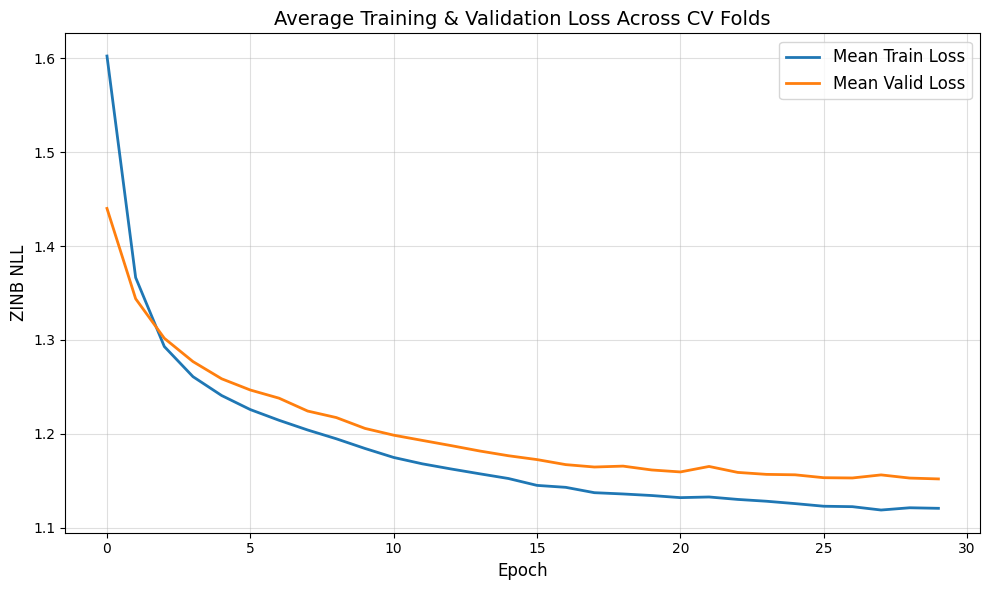


Summary of CV Training
Mean Final Train Loss = 1.1208
Mean Final Valid Loss = 1.1521


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

avg_train = np.mean(np.array(cv_train_curves), axis=0)
avg_valid = np.mean(np.array(cv_valid_curves), axis=0)

plt.figure(figsize=(10, 6))
plt.plot(avg_train, label="Mean Train Loss", linewidth=2)
plt.plot(avg_valid, label="Mean Valid Loss", linewidth=2)

plt.title("Average Training & Validation Loss Across CV Folds", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("ZINB NLL", fontsize=12)
plt.grid(True, alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print("\nSummary of CV Training")
print(f"Mean Final Train Loss = {avg_train[-1]:.4f}")
print(f"Mean Final Valid Loss = {avg_valid[-1]:.4f}")

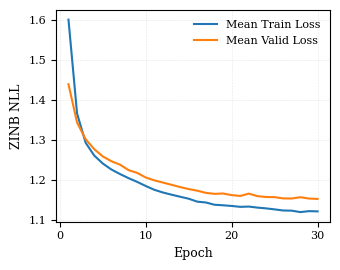


Summary of CV Training
Mean Final Train Loss = 1.1208
Mean Final Valid Loss = 1.1521
Figure saved to: /content/drive/MyDrive/cv_loss_curve_stgnn.eps


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ----- Save location -----
save_path = "/content/drive/MyDrive/cv_loss_curve_stgnn.eps"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# ----- Convert curves and take mean -----
avg_train = np.mean(np.array(cv_train_curves), axis=0)
avg_valid = np.mean(np.array(cv_valid_curves), axis=0)

# ----- Define x-axis for epochs -----
epochs = np.arange(1, len(avg_train) + 1)  # ensures the curve reaches the final epoch

# ----- Springer single-column figure -----
plt.figure(figsize=(3.5, 2.8))  # width ~3.5 inches

plt.plot(epochs, avg_train, linewidth=1.5, label="Mean Train Loss")
plt.plot(epochs, avg_valid, linewidth=1.5, label="Mean Valid Loss")

# Labels
plt.xlabel("Epoch", fontsize=9)
plt.ylabel("ZINB NLL", fontsize=9)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.grid(True, linestyle="--", color="gray", linewidth=0.4, alpha=0.2) # subtle gray lines
plt.legend(fontsize=8, frameon=False)

plt.tight_layout()

# ----- Save figure as EPS -----
plt.savefig(save_path, format="eps", bbox_inches="tight")
plt.show()

# ----- Summary -----
print("\nSummary of CV Training")
print(f"Mean Final Train Loss = {avg_train[-1]:.4f}")
print(f"Mean Final Valid Loss = {avg_valid[-1]:.4f}")
print(f"Figure saved to: {save_path}")

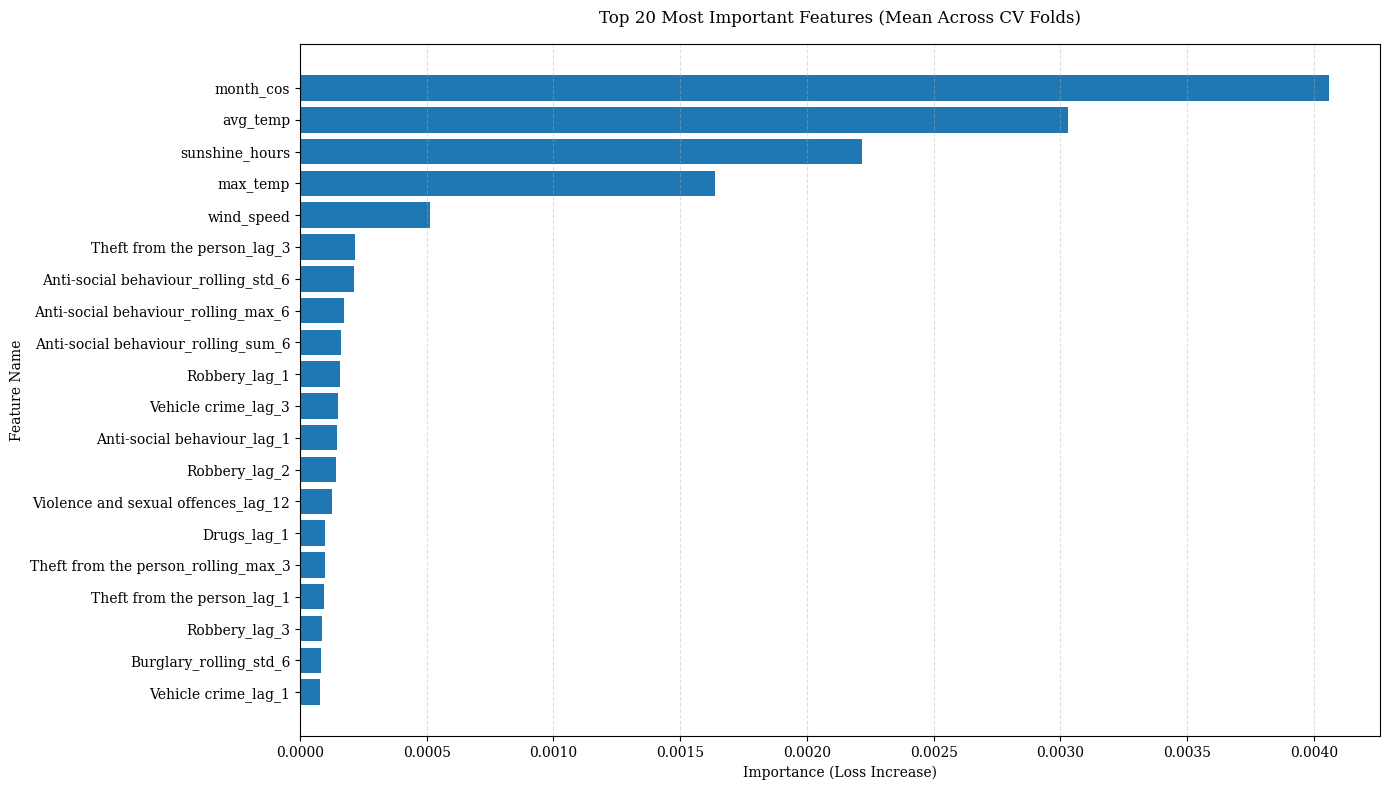

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

imp_df = pd.DataFrame(all_fold_importances) # Convert list of dicts -> DataFrame (folds × features)

mean_importance = imp_df.mean().sort_values(ascending=False)

top_k = 20
plt.figure(figsize=(14, 8))
plt.barh(mean_importance.head(top_k).index[::-1],  # reverse order → highest on top
         mean_importance.head(top_k).values[::-1])

plt.title("Top 20 Most Important Features (Mean Across CV Folds)", pad=15)
plt.xlabel("Importance (Loss Increase)")
plt.ylabel("Feature Name")

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

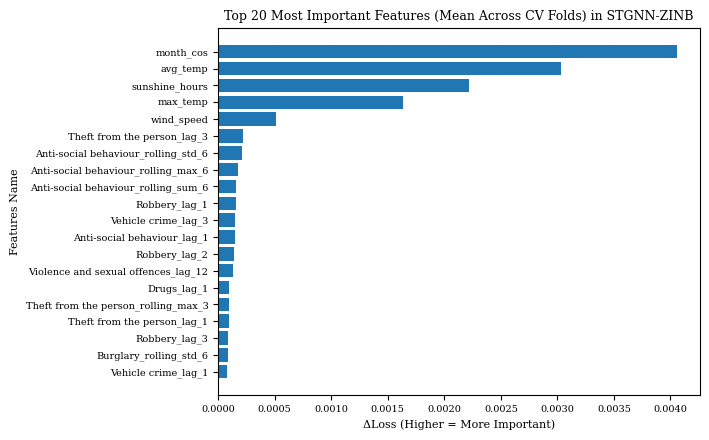

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert list of dicts -> DataFrame (folds × features)
imp_df = pd.DataFrame(all_fold_importances)

# Mean importance across folds
mean_importance = imp_df.mean().sort_values(ascending=False)

top_k = 20

# Springer single-column width (~3.5 inches)
plt.figure(figsize=(7.2, 4.5))

plt.barh(
    mean_importance.head(top_k).index[::-1],
    mean_importance.head(top_k).values[::-1]
)

plt.title("Top 20 Most Important Features (Mean Across CV Folds) in STGNN-ZINB", fontsize=9)
plt.xlabel("ΔLoss (Higher = More Important)", fontsize=8)
plt.ylabel("Features Name", fontsize=8)

plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.grid(axis='x', linestyle="--", color="gray", linewidth=0.1, alpha=0.1)

plt.tight_layout()

# Save as EPS for Springer
plt.savefig("/content/drive/MyDrive/feature_importance.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
selected_features = mean_importance[mean_importance > 0].index.tolist()
print("Number of selected features:", len(selected_features))

Number of selected features: 67


In [ ]:
all_months = sorted(csv_data["Month"].unique())

test_months = all_months[-TEST_SIZE_MONTHS:]
train_val_months = all_months[:-TEST_SIZE_MONTHS]

train_val_df = csv_data[csv_data["Month"].isin(train_val_months)].copy()
test_df      = csv_data[csv_data["Month"].isin(test_months)].copy()

folds = make_month_folds(
    month_list=train_val_months,
    val_size=VAL_SIZE_MONTHS,
    min_train_months=NEEDED_MONTHS
)

print(f"Number of CV folds: {len(folds)}")
for i, (tr_m, va_m) in enumerate(folds, 1):
    print(f"Fold {i}: Train {len(tr_m)} months, Valid {len(va_m)} months")

Number of CV folds: 4
Fold 1: Train 16 months, Valid 16 months
Fold 2: Train 32 months, Valid 16 months
Fold 3: Train 48 months, Valid 16 months
Fold 4: Train 64 months, Valid 16 months


In [ ]:
def scale_subset(df_train, df_valid, features_to_scale):
    df_train_scaled = df_train.copy()
    df_valid_scaled = df_valid.copy()

    z_cols_selected = [f for f in features_to_scale if f in z_columns]
    robust_cols_selected = [f for f in features_to_scale if f in robust_columns]

    scaler_standard = StandardScaler()
    scaler_robust   = RobustScaler(quantile_range=(10, 90))

    if len(z_cols_selected) > 0:
        scaler_standard.fit(df_train_scaled[z_cols_selected])
        df_train_scaled[z_cols_selected] = scaler_standard.transform(df_train_scaled[z_cols_selected])
        df_valid_scaled[z_cols_selected] = scaler_standard.transform(df_valid_scaled[z_cols_selected])

    if len(robust_cols_selected) > 0:
        scaler_robust.fit(df_train_scaled[robust_cols_selected])
        df_train_scaled[robust_cols_selected] = scaler_robust.transform(df_train_scaled[robust_cols_selected])
        df_valid_scaled[robust_cols_selected] = scaler_robust.transform(df_valid_scaled[robust_cols_selected])

    return df_train_scaled, df_valid_scaled

In [ ]:
BATCH = 4
EPOCHS = 30

cv_train_curves_after = []   # store each fold's training loss per epoch
cv_valid_curves_after = []   # store each fold's validation loss per epoch
cv_losses_after_selection = []  # final validation loss per fold

for fold_idx, (train_months, valid_months) in enumerate(folds, 1):
    print(f"==================== Fold {fold_idx} ====================")

    df_train = train_val_df[train_val_df["Month"].isin(train_months)].copy()
    df_valid = train_val_df[train_val_df["Month"].isin(valid_months)].copy()

    if df_train["Month"].nunique() < NEEDED_MONTHS:
        print("Skipping fold — insufficient training months.")
        continue
    if df_valid["Month"].nunique() < NEEDED_MONTHS:
        print("Skipping fold — insufficient validation months.")
        continue

    df_train_scaled, df_valid_scaled = scale_subset(
        df_train, df_valid, selected_features
    )

    train_dataset = STGNNCrimeDataset(
        df_train_scaled, selected_features, crime_columns,
        seq_len=SEQ_LEN, horizon=HORIZON
    )
    valid_dataset = STGNNCrimeDataset(
        df_valid_scaled, selected_features, crime_columns,
        seq_len=SEQ_LEN, horizon=HORIZON
    )

    if len(train_dataset) == 0 or len(valid_dataset) == 0:
        print("Skipping fold — empty dataset.")
        continue

    train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH, shuffle=False)

    N_nodes = train_dataset.X.shape[1]
    F_feats = train_dataset.X.shape[2]

    model2 = DiffusionSTGNN_ZINB(
        num_nodes=N_nodes,
        num_features=F_feats,
        num_crimes=len(crime_columns),
        horizon=HORIZON,
        knn_adj=knn_adj,
        hidden_dim=96,
        num_heads=4,
        dropout=0.1,
        diff_hops=2
    ).to(device)

    optimizer = torch.optim.Adam(model2.parameters(), lr=1e-3)

    train_epoch_losses = []
    valid_epoch_losses = []

    for epoch in range(1, EPOCHS + 1):
        model2.train()
        batch_losses = []
        for Xb, Yb in train_loader:
            Xb, Yb = Xb.to(device), Yb.to(device)
            optimizer.zero_grad()
            pi, mu, r = model2(Xb)
            loss = zinb_nll(Yb, pi, mu, r)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_epoch_loss = np.mean(batch_losses)
        train_epoch_losses.append(train_epoch_loss)

        # Validation
        model2.eval()
        val_losses_epoch = []
        with torch.no_grad():
            for Xb, Yb in valid_loader:
                Xb, Yb = Xb.to(device), Yb.to(device)
                pi, mu, r = model2(Xb)
                val_losses_epoch.append(zinb_nll(Yb, pi, mu, r).item())
        valid_epoch_loss = np.mean(val_losses_epoch)
        valid_epoch_losses.append(valid_epoch_loss)

        print(f"Fold {fold_idx} | Epoch {epoch:02d}/{EPOCHS} "
              f"| Train NLL: {train_epoch_loss:.4f} "
              f"| Valid NLL: {valid_epoch_loss:.4f}")

    # Store curves
    cv_train_curves_after.append(train_epoch_losses)
    cv_valid_curves_after.append(valid_epoch_losses)

    # Final validation loss of this fold
    final_val_loss = valid_epoch_losses[-1]
    cv_losses_after_selection.append(final_val_loss)

    print(f"Fold {fold_idx} | Final Validation Loss: {final_val_loss:.4f}")

==================== Fold 1 ====================
Fold 1 | Epoch 01/30 | Train NLL: 1.7540 | Valid NLL: 1.7442
Fold 1 | Epoch 02/30 | Train NLL: 1.5627 | Valid NLL: 1.6630
Fold 1 | Epoch 03/30 | Train NLL: 1.5039 | Valid NLL: 1.6086
Fold 1 | Epoch 04/30 | Train NLL: 1.4610 | Valid NLL: 1.5631
Fold 1 | Epoch 05/30 | Train NLL: 1.4249 | Valid NLL: 1.5249
Fold 1 | Epoch 06/30 | Train NLL: 1.3918 | Valid NLL: 1.4896
Fold 1 | Epoch 07/30 | Train NLL: 1.3599 | Valid NLL: 1.4572
Fold 1 | Epoch 08/30 | Train NLL: 1.3298 | Valid NLL: 1.4285
Fold 1 | Epoch 09/30 | Train NLL: 1.3021 | Valid NLL: 1.4038
Fold 1 | Epoch 10/30 | Train NLL: 1.2785 | Valid NLL: 1.3830
Fold 1 | Epoch 11/30 | Train NLL: 1.2577 | Valid NLL: 1.3666
Fold 1 | Epoch 12/30 | Train NLL: 1.2403 | Valid NLL: 1.3545
Fold 1 | Epoch 13/30 | Train NLL: 1.2242 | Valid NLL: 1.3460
Fold 1 | Epoch 14/30 | Train NLL: 1.2103 | Valid NLL: 1.3403
Fold 1 | Epoch 15/30 | Train NLL: 1.1977 | Valid NLL: 1.3369
Fold 1 | Epoch 16/30 | Train NLL: 1.

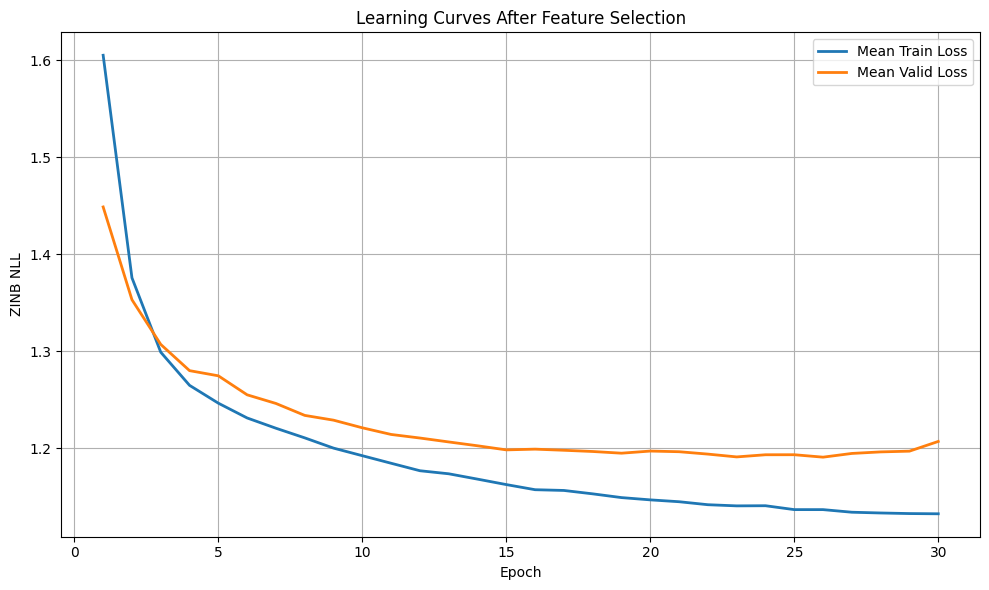

Average CV Train Loss: 1.1324
Average CV Valid Loss: 1.2070


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

train_curves = np.array(cv_train_curves_after, dtype=object)
valid_curves = np.array(cv_valid_curves_after, dtype=object)

# Mean curves
mean_train = np.mean(np.vstack(train_curves), axis=0)
mean_valid = np.mean(np.vstack(valid_curves), axis=0)

epochs = range(1, len(mean_train) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, mean_train, label="Mean Train Loss", linewidth=2)
plt.plot(epochs, mean_valid, label="Mean Valid Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("ZINB NLL")
plt.title("Learning Curves After Feature Selection")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average CV Train Loss: {mean_train[-1]:.4f}")
print(f"Average CV Valid Loss: {mean_valid[-1]:.4f}")

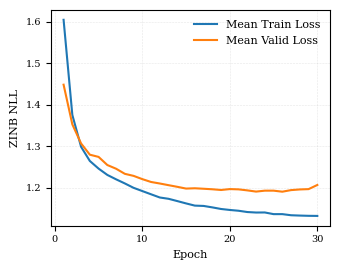

Average CV Train Loss: 1.1324
Average CV Valid Loss: 1.2070


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

train_curves = np.array(cv_train_curves_after, dtype=object)
valid_curves = np.array(cv_valid_curves_after, dtype=object)

# Mean curves
mean_train = np.mean(np.vstack(train_curves), axis=0)
mean_valid = np.mean(np.vstack(valid_curves), axis=0)

epochs = range(1, len(mean_train) + 1)

# Springer single-column size
plt.figure(figsize=(3.5, 2.8))

plt.plot(epochs, mean_train, label="Mean Train Loss", linewidth=1.5)
plt.plot(epochs, mean_valid, label="Mean Valid Loss", linewidth=1.5)

plt.xlabel("Epoch", fontsize=8)
plt.ylabel("ZINB NLL", fontsize=8)

plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.grid(True, linestyle="--", color="gray", linewidth=0.4, alpha=0.2)
plt.legend(fontsize=8, frameon=False)

plt.tight_layout()

# Save as EPS for Springer
plt.savefig("/content/drive/MyDrive/learning_curves_after_fs_stgnn.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

print(f"Average CV Train Loss: {mean_train[-1]:.4f}")
print(f"Average CV Valid Loss: {mean_valid[-1]:.4f}")

In [ ]:
z_cols_selected = [f for f in selected_features if f in z_columns]
robust_cols_selected = [f for f in selected_features if f in robust_columns]

train_val_scaled = train_val_df.copy()
test_scaled = test_df.copy()  # will be scaled after fitting scalers

scaler_standard = StandardScaler()
scaler_robust = RobustScaler(quantile_range=(10, 90))

if len(z_cols_selected) > 0:
    scaler_standard.fit(train_val_df[z_cols_selected])
    train_val_scaled[z_cols_selected] = scaler_standard.transform(train_val_df[z_cols_selected])
    test_scaled[z_cols_selected]      = scaler_standard.transform(test_df[z_cols_selected])

if len(robust_cols_selected) > 0:
    scaler_robust.fit(train_val_df[robust_cols_selected])
    train_val_scaled[robust_cols_selected] = scaler_robust.transform(train_val_df[robust_cols_selected])
    test_scaled[robust_cols_selected]      = scaler_robust.transform(test_df[robust_cols_selected])

final_train_dataset = STGNNCrimeDataset(
    train_val_scaled, selected_features, crime_columns,
    seq_len=SEQ_LEN, horizon=HORIZON
)
final_test_dataset = STGNNCrimeDataset(
    test_scaled, selected_features, crime_columns,
    seq_len=SEQ_LEN, horizon=HORIZON
)

final_train_loader = DataLoader(final_train_dataset, batch_size=BATCH, shuffle=True)
final_test_loader  = DataLoader(final_test_dataset, batch_size=BATCH, shuffle=False)

print(f"Train sequences: {len(final_train_dataset)}")
print(f"Test sequences:  {len(final_test_dataset)}")

Train sequences: 73
Test sequences:  1


In [ ]:
N_nodes = final_train_dataset.X.shape[1]
F_feats = final_train_dataset.X.shape[2]

final_model = DiffusionSTGNN_ZINB(
    num_nodes=N_nodes,
    num_features=F_feats,
    num_crimes=len(crime_columns),
    horizon=HORIZON,
    knn_adj=knn_adj,
    hidden_dim=96,
    num_heads=4,
    dropout=0.1,
    diff_hops=2
).to(device)

optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-3)

print("FINAL MODEL")

best_loss = float("inf")
patience = 5
patience_counter = 0
min_delta = 1e-4
best_epoch = 0
EPOCHS = 40

for epoch in range(1, EPOCHS + 1):
    final_model.train()
    train_losses = []

    for Xb, Yb in final_train_loader:
        Xb, Yb = Xb.to(device), Yb.to(device)

        optimizer.zero_grad()
        pi, mu, r = final_model(Xb)
        loss = zinb_nll(Yb, pi, mu, r)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    mean_loss = np.mean(train_losses)
    print(f"Epoch {epoch}| Train NLL: {mean_loss:.4f}")

    # ---- EARLY STOPPING ----
    if (best_loss - mean_loss) > min_delta:
        best_loss = mean_loss
        patience_counter = 0
        best_epoch = epoch

        # Save best model checkpoint
        torch.save(final_model.state_dict(), "/content/drive/MyDrive/final_STGNN_ZINB_BEST.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

print("\nFinal training completed.")
print(f"Best epoch: {best_epoch} | Best Train Loss: {best_loss:.4f}")
print("Best model saved → /content/drive/MyDrive/final_STGNN_ZINB_BEST.pth")

FINAL MODEL
Epoch 1| Train NLL: 1.4207
Epoch 2| Train NLL: 1.1940
Epoch 3| Train NLL: 1.1697
Epoch 4| Train NLL: 1.1597
Epoch 5| Train NLL: 1.1567
Epoch 6| Train NLL: 1.1498
Epoch 7| Train NLL: 1.1462
Epoch 8| Train NLL: 1.1475
Epoch 9| Train NLL: 1.1400
Epoch 10| Train NLL: 1.1355
Epoch 11| Train NLL: 1.1326
Epoch 12| Train NLL: 1.1295
Epoch 13| Train NLL: 1.1274
Epoch 14| Train NLL: 1.1240
Epoch 15| Train NLL: 1.1242
Epoch 16| Train NLL: 1.1198
Epoch 17| Train NLL: 1.1203
Epoch 18| Train NLL: 1.1202
Epoch 19| Train NLL: 1.1166
Epoch 20| Train NLL: 1.1194
Epoch 21| Train NLL: 1.1177
Epoch 22| Train NLL: 1.1153
Epoch 23| Train NLL: 1.1147
Epoch 24| Train NLL: 1.1120
Epoch 25| Train NLL: 1.1118
Epoch 26| Train NLL: 1.1109
Epoch 27| Train NLL: 1.1162
Epoch 28| Train NLL: 1.1194
Epoch 29| Train NLL: 1.1150
Epoch 30| Train NLL: 1.1111
Epoch 31| Train NLL: 1.1087
Epoch 32| Train NLL: 1.1087
Epoch 33| Train NLL: 1.1071
Epoch 34| Train NLL: 1.1079
Epoch 35| Train NLL: 1.1069
Epoch 36| Train N


# Negative Log-Likelihood (NLL) Per Crime Types

In [ ]:
with torch.no_grad():
    pi, mu, r = final_model(Xb.to(device))

nll_tensor = zinb_nll(Yb.to(device), pi, mu, r, reduction=None)
zinb_nll_per_crime = nll_tensor.mean(dim=(0,1,2))

pairs = list(zip(crime_columns, zinb_nll_per_crime.tolist()))
pairs_sorted = sorted(pairs, key=lambda x: x[1])

for name, nll in pairs_sorted:
    probability = torch.exp(-torch.tensor(nll)).item()
    probability_pct = probability * 100
    print(f"{name:30s}: NLL = {nll:.4f} -> p = ({probability_pct:.2f}%)")

Possession of weapons         : NLL = 0.2713 -> p = (76.24%)
Other crime                   : NLL = 0.4406 -> p = (64.36%)
Shoplifting                   : NLL = 0.5920 -> p = (55.32%)
Bicycle theft                 : NLL = 0.6118 -> p = (54.24%)
Theft from the person         : NLL = 0.6615 -> p = (51.61%)
Robbery                       : NLL = 0.7010 -> p = (49.61%)
Drugs                         : NLL = 0.9653 -> p = (38.09%)
Criminal damage and arson     : NLL = 1.2084 -> p = (29.87%)
Public order                  : NLL = 1.2114 -> p = (29.78%)
Burglary                      : NLL = 1.2325 -> p = (29.16%)
Other theft                   : NLL = 1.4153 -> p = (24.28%)
Vehicle crime                 : NLL = 1.6669 -> p = (18.88%)
Violence and sexual offences  : NLL = 2.1771 -> p = (11.34%)
Anti-social behaviour         : NLL = 2.1802 -> p = (11.30%)


# 3.4 Evaluation

## (i) Discrete Metrics (True Zero Rate for zero-crime cases & F1-Score for crime-occurred cases)

In [ ]:
import numpy as np
from sklearn.metrics import f1_score
import torch

final_model.eval()

with torch.no_grad():
    all_y_true, all_y_pred, all_r = [], [], []

    for Xb, Yb in final_test_loader:
        Xb, Yb = Xb.to(device), Yb.to(device)
        pi, mu, r = final_model(Xb)

        y_pred = (1 - pi) * mu

        y_pred = y_pred.cpu().numpy().astype(np.float64)
        y_true = Yb.cpu().numpy().astype(np.float64)
        r_np   = r.cpu().numpy().astype(np.float64)

        y_pred = np.clip(y_pred, 0, None)
        y_true = np.clip(y_true, 0, None)

        all_y_pred.append(y_pred)
        all_y_true.append(y_true)
        all_r.append(r_np)

y_pred_all = np.concatenate(all_y_pred, axis=0)
y_true_all = np.concatenate(all_y_true, axis=0)
r_all      = np.concatenate(all_r, axis=0)

tzr_f1_list = []

for i, crime in enumerate(crime_columns):
    y_true_flat = y_true_all[..., i].ravel()
    y_pred_flat = y_pred_all[..., i].ravel()

    y_true_bin = (y_true_flat > 0).astype(int)
    y_pred_bin = (y_pred_flat > 0.5).astype(int)   # threshold

    # True Zero Rate
    zero_mask = (y_true_flat == 0)
    if zero_mask.sum() > 0:
        correct_zeros = np.sum((y_pred_bin == 0) & zero_mask)
        tzr = correct_zeros / zero_mask.sum()
    else:
        tzr = np.nan

    # F1
    if len(np.unique(y_true_bin)) > 1:
        f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    else:
        f1 = np.nan

    tzr_f1_list.append((crime, tzr, f1))

valid_metrics = [x for x in tzr_f1_list if not np.isnan(x[1]) and not np.isnan(x[2])]
tzr_f1_sorted = sorted(valid_metrics, key=lambda x: x[2], reverse=True)

print("Discrete Metrics (True Zero Rate & F1 sorted by F1)")
print(f"{'Crime Type':30s} | {'True Zero Rate':>15s} | {'F1 Score':>10s}")
print("-" * 65)
for c, z, f in tzr_f1_sorted:
    print(f"{c:30s} | {z:15.3f} | {f:10.3f}")

print("\nGlobal Averages:")
print(f"True Zero Rate = {np.nanmean([z for _, z, _ in tzr_f1_sorted]):.3f}")
print(f"F1 Score       = {np.nanmean([f for _, _, f in tzr_f1_sorted]):.3f}")

Discrete Metrics (True Zero Rate & F1 sorted by F1)
Crime Type                     |  True Zero Rate |   F1 Score
-----------------------------------------------------------------
Violence and sexual offences   |           0.292 |      0.951
Anti-social behaviour          |           0.218 |      0.929
Vehicle crime                  |           0.134 |      0.801
Other theft                    |           0.407 |      0.746
Shoplifting                    |           0.876 |      0.723
Criminal damage and arson      |           0.455 |      0.697
Public order                   |           0.510 |      0.697
Theft from the person          |           0.889 |      0.644
Burglary                       |           0.499 |      0.629
Drugs                          |           0.747 |      0.612
Robbery                        |           0.853 |      0.560
Bicycle theft                  |           0.927 |      0.451
Possession of weapons          |           0.996 |      0.118
Other crime   

# (ii) Uncertainty Metrics - KL Divergence (Kullback-Leibler Divergence)

In [ ]:
all_y_true = []
all_pi = []
all_mu = []
all_r  = []

with torch.no_grad():
    final_model.eval()

    for Xb, Yb in final_test_loader:
        Xb = Xb.to(device)
        Yb = Yb.to(device)

        pi, mu, r = final_model(Xb)

        all_y_true.append(Yb.cpu())
        all_pi.append(pi.cpu())
        all_mu.append(mu.cpu())
        all_r.append(r.cpu())

y_true_all = torch.cat(all_y_true, dim=0)
pi_all     = torch.cat(all_pi,   dim=0)
mu_all     = torch.cat(all_mu,   dim=0)
r_all      = torch.cat(all_r,    dim=0)

kl_list = []

for i, crime in enumerate(crime_columns):
    kl = zinb_nll(
        y_true_all[..., i],   # true counts
        pi_all[..., i],       # zero inflation prob
        mu_all[..., i],       # mean
        r_all[..., i],        # dispersion
        reduction="mean"
    ).item()

    kl_list.append((crime, kl))

kl_sorted = sorted(kl_list, key=lambda x: x[1])

print("KL Divergence per Crime Type (ZINB-NLL based)")
print(f"{'Crime Type':30s} | {'KL':>10s}")
print("-" * 50)
for c, v in kl_sorted:
    print(f"{c:30s} | {v:10.3f}")

print("\nGlobal Mean KL:", np.mean([v for _,v in kl_sorted]))

KL Divergence per Crime Type (ZINB-NLL based)
Crime Type                     |         KL
--------------------------------------------------
Possession of weapons          |      0.298
Bicycle theft                  |      0.476
Other crime                    |      0.487
Robbery                        |      0.747
Shoplifting                    |      0.862
Theft from the person          |      0.918
Burglary                       |      1.049
Public order                   |      1.177
Drugs                          |      1.185
Criminal damage and arson      |      1.201
Other theft                    |      1.314
Vehicle crime                  |      1.434
Violence and sexual offences   |      2.154
Anti-social behaviour          |      2.162

Global Mean KL: 1.1044089049100876


# 4. LSTM_ZINB Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as fn

class LSTM_ZINB(nn.Module):
    def __init__(self, num_features, num_crimes, horizon,
                 hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()

        self.horizon = horizon
        self.num_crimes = num_crimes

        # LSTM with dropout between stacked layers
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

        out_dim = horizon * num_crimes

        # ZINB heads
        self.pi_head = nn.Linear(hidden_dim, out_dim)
        self.mu_head = nn.Linear(hidden_dim, out_dim)
        self.r_head  = nn.Linear(hidden_dim, out_dim)

    def forward(self, X):
        """
        X: [B, T, F]  (no node dimension, spatially aggregated beforehand)
        """
        B = X.size(0)

        h, _ = self.lstm(X)            # [B, T, H]
        h_last = self.dropout(h[:, -1])  # [B, H]

        pi_logits = self.pi_head(h_last)
        mu_raw    = self.mu_head(h_last)
        r_raw     = self.r_head(h_last)

        pi = torch.sigmoid(pi_logits)
        mu = fn.softplus(mu_raw) + 1e-6
        r  = fn.softplus(r_raw)  + 1e-6

        return (
            pi.view(B, self.horizon, self.num_crimes),
            mu.view(B, self.horizon, self.num_crimes),
            r.view(B, self.horizon, self.num_crimes)
        )

In [ ]:
def evaluate_loss_lstm(model, loader, device):
    """
    Evaluate ZINB NLL for LSTM model on a given DataLoader.
    Assumes:
      - X: [B, T, N, F] from STGNNCrimeDataset
      - Y: [B, N, H, C]
    We average over nodes to get a city-wide baseline:
      - X_agg: [B, T, F]
      - Y_agg: [B, H, C]
    """
    model.eval()
    losses = []
    with torch.no_grad():
        for Xb, Yb in loader:
            Xb = Xb.to(device)         # [B, T, N, F]
            Yb = Yb.to(device)         # [B, N, H, C]

            B, T, N, F = Xb.shape

            Xb2 = Xb.permute(0, 2, 1, 3).reshape(B * N, T, F)
            Yb2 = Yb.reshape(B * N, Yb.shape[2], Yb.shape[3])

            pi, mu, r = LSTM_ZINBmodel(Xb2)
            loss = zinb_nll(Yb2, pi, mu, r)
            losses.append(loss.item())

    return float(np.mean(losses)) if len(losses) > 0 else np.nan

In [ ]:
def permutation_feature_importance_lstm(model, dataset, loader, feature_cols, device, repeats=1):
    """
    Permutation importance for LSTM_ZINB baseline.
    - dataset.X: [T, N, F]
    - For each feature f, we permute its values across time (T axis),
      evaluate loss, and measure how much worse it gets.
    """
    base_loss = evaluate_loss_lstm(model, loader, device)
    print(f"Base validation loss (LSTM): {base_loss:.4f}")

    importances = {feat: 0.0 for feat in feature_cols}

    for feat_index, feat_name in enumerate(feature_cols):
        losses = []

        for _ in range(repeats):
            # Copy original X
            X_perm = dataset.X.clone()             # [T, N, F]

            # Permute feature f across time
            noise = X_perm[:, :, feat_index].clone()          # [T, N]
            perm_idx = torch.randperm(noise.size(0))          # permute T dimension
            noise = noise[perm_idx]                           # [T, N] shuffled over time
            X_perm[:, :, feat_index] = noise

            saved_X = dataset.X
            dataset.X = X_perm

            loss = evaluate_loss_lstm(model, loader, device)
            losses.append(loss)

            dataset.X = saved_X

        importances[feat_name] = np.mean(losses) - base_loss

    return importances

In [ ]:
BATCH = 4
EPOCHS = 30

cv_train_curves_LSTM = []
cv_valid_curves_LSTM = []
cv_val_losses_mean_LSTM = []
all_fold_importances_LSTM = []

print(f"Total LSTM CV folds: {len(folds)}\n")

for fold_idx, (train_months_fold, valid_months_fold) in enumerate(folds, 1):
    print(f"\n================ LSTM Fold {fold_idx} ================")
    print("Train months:", train_months_fold[0], "→", train_months_fold[-1])
    print("Valid months:", valid_months_fold[0], "→", valid_months_fold[-1])

    # Slice data
    df_train = train_val_df[train_val_df["Month"].isin(train_months_fold)].copy()
    df_valid = train_val_df[train_val_df["Month"].isin(valid_months_fold)].copy()

    if df_train["Month"].nunique() < NEEDED_MONTHS or df_valid["Month"].nunique() < NEEDED_MONTHS:
        print("Skipping fold — insufficient months.")
        continue

    # Scaling
    scaler_standard = StandardScaler()
    scaler_robust   = RobustScaler(quantile_range=(10, 90))

    scaler_standard.fit(df_train[z_columns])
    scaler_robust.fit(df_train[robust_columns])

    df_train[z_columns] = scaler_standard.transform(df_train[z_columns])
    df_valid[z_columns] = scaler_standard.transform(df_valid[z_columns])

    df_train[robust_columns] = scaler_robust.transform(df_train[robust_columns])
    df_valid[robust_columns] = scaler_robust.transform(df_valid[robust_columns])

    train_dataset = STGNNCrimeDataset(
        df_train, feature_cols, crime_columns,
        seq_len=SEQ_LEN, horizon=HORIZON
    )
    valid_dataset = STGNNCrimeDataset(
        df_valid, feature_cols, crime_columns,
        seq_len=SEQ_LEN, horizon=HORIZON
    )

    if len(train_dataset) == 0 or len(valid_dataset) == 0:
        print("Skipping fold — empty sequences.")
        continue

    train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH, shuffle=False)

    N_nodes = train_dataset.X.shape[1]
    F_feats = train_dataset.X.shape[2]

    # LSTM-ZINB Model
    LSTM_ZINBmodel = LSTM_ZINB(
        num_features=F_feats,
        num_crimes=len(crime_columns),
        horizon=HORIZON,
        hidden_dim=64,
        num_layers=2,
        dropout=0.3
    ).to(device)

    optimizer = torch.optim.Adam(LSTM_ZINBmodel.parameters(), lr=1e-3)

    train_curve = []
    valid_curve = []

    # Training Loop
    for epoch in range(1, EPOCHS + 1):
        LSTM_ZINBmodel.train()
        batch_losses = []

        for Xb, Yb in train_loader:
            Xb = Xb.to(device)     # [B, T, N, F]
            Yb = Yb.to(device)     # [B, N, H, C]

            B, T, N, F = Xb.shape

            # Flatten spatial dimension → model learns per-node patterns
            Xb2 = Xb.permute(0, 2, 1, 3).reshape(B * N, T, F)       # [B*N, T, F]
            Yb2 = Yb.reshape(B * N, Yb.shape[2], Yb.shape[3])       # [B*N, H, C]

            optimizer.zero_grad()
            pi, mu, r = LSTM_ZINBmodel(Xb2)
            loss = zinb_nll(Yb2, pi, mu, r)
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        train_epoch_loss = float(np.mean(batch_losses))
        train_curve.append(train_epoch_loss)

        # Validation
        valid_epoch_loss = evaluate_loss_lstm(LSTM_ZINBmodel, valid_loader, device)
        valid_curve.append(valid_epoch_loss)

        print(f"Fold {fold_idx} | Epoch {epoch}/{EPOCHS} | "
              f"Train NLL: {train_epoch_loss:.4f} | "
              f"Valid NLL: {valid_epoch_loss:.4f}")

    cv_train_curves_LSTM.append(train_curve)
    cv_valid_curves_LSTM.append(valid_curve)
    cv_val_losses_mean_LSTM.append(valid_curve[-1])

    print(f"Fold {fold_idx} finished | Final LSTM Valid NLL: {valid_curve[-1]:.4f}")

    # Permutation Feature Importance
    print(f"\nComputing LSTM permutation feature importance for Fold {fold_idx}...")
    fold_importance = permutation_feature_importance_lstm(
        model=LSTM_ZINBmodel,
        dataset=valid_dataset,
        loader=valid_loader,
        feature_cols=train_dataset.feature_cols,
        device=device,
        repeats=1
    )

    all_fold_importances_LSTM.append(fold_importance)

print("\n================ LSTM CV Summary ================")
print("Final validation NLL per fold:", cv_val_losses_mean_LSTM)
print("Mean LSTM CV validation NLL:", np.mean(cv_val_losses_mean_LSTM))

Total LSTM CV folds: 4


================ LSTM Fold 1 ================
Train months: 2017-01 → 2018-04
Valid months: 2018-05 → 2019-08
Fold 1 | Epoch 1/30 | Train NLL: 1.6856 | Valid NLL: 1.8487
Fold 1 | Epoch 2/30 | Train NLL: 1.6784 | Valid NLL: 1.8405
Fold 1 | Epoch 3/30 | Train NLL: 1.6712 | Valid NLL: 1.8318
Fold 1 | Epoch 4/30 | Train NLL: 1.6637 | Valid NLL: 1.8222
Fold 1 | Epoch 5/30 | Train NLL: 1.6559 | Valid NLL: 1.8110
Fold 1 | Epoch 6/30 | Train NLL: 1.6464 | Valid NLL: 1.7980
Fold 1 | Epoch 7/30 | Train NLL: 1.6358 | Valid NLL: 1.7828
Fold 1 | Epoch 8/30 | Train NLL: 1.6233 | Valid NLL: 1.7654
Fold 1 | Epoch 9/30 | Train NLL: 1.6097 | Valid NLL: 1.7458
Fold 1 | Epoch 10/30 | Train NLL: 1.5940 | Valid NLL: 1.7242
Fold 1 | Epoch 11/30 | Train NLL: 1.5766 | Valid NLL: 1.7010
Fold 1 | Epoch 12/30 | Train NLL: 1.5580 | Valid NLL: 1.6767
Fold 1 | Epoch 13/30 | Train NLL: 1.5386 | Valid NLL: 1.6518
Fold 1 | Epoch 14/30 | Train NLL: 1.5196 | Valid NLL: 1.6268
Fold 1 | Epoch 15/30

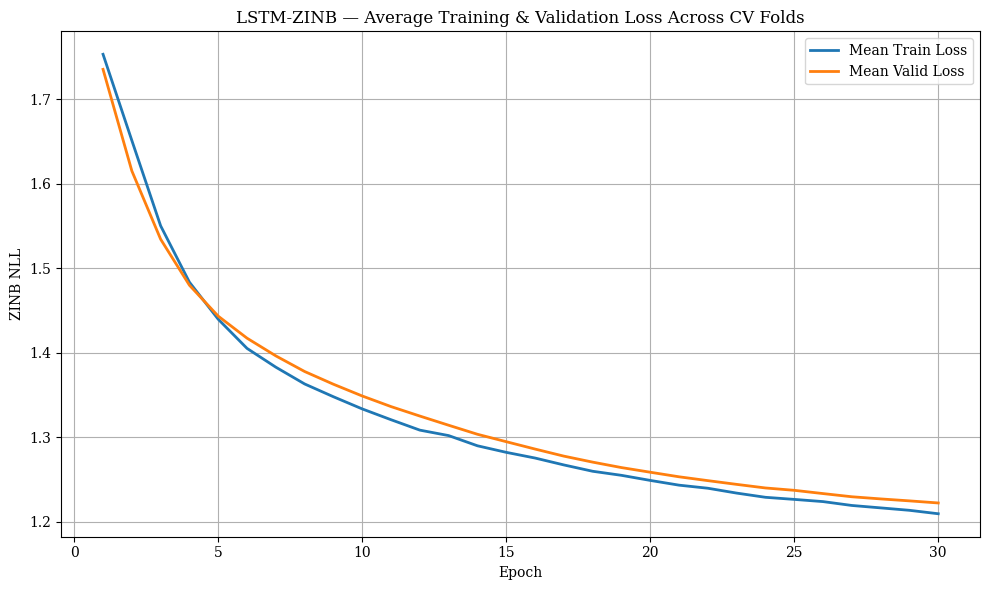

Average Final Training Loss = 1.2097
Average Final Validation Loss = 1.2225


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

train_array = np.array(cv_train_curves_LSTM)
valid_array = np.array(cv_valid_curves_LSTM)

mean_train = train_array.mean(axis=0)
mean_valid = valid_array.mean(axis=0)

epochs = np.arange(1, len(mean_train) + 1)

plt.figure(figsize=(10,6))

plt.plot(epochs, mean_train, label="Mean Train Loss", linewidth=2)
plt.plot(epochs, mean_valid, label="Mean Valid Loss", linewidth=2)

plt.title("LSTM-ZINB — Average Training & Validation Loss Across CV Folds")
plt.xlabel("Epoch")
plt.ylabel("ZINB NLL")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Average Final Training Loss = {mean_train[-1]:.4f}")
print(f"Average Final Validation Loss = {mean_valid[-1]:.4f}")

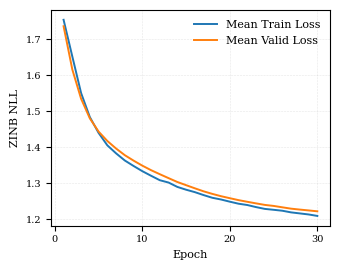

Figure saved to: /content/drive/MyDrive/lstm_learning_curve.eps
Average Final Training Loss = 1.2097
Average Final Validation Loss = 1.2225


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ----- Save location -----
save_path = "/content/drive/MyDrive/lstm_learning_curve.eps"  # change folder if needed
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# ----- Academic font style -----
plt.rcParams["font.family"] = "serif"

# ----- Convert curves -----
train_array = np.array(cv_train_curves_LSTM)
valid_array = np.array(cv_valid_curves_LSTM)

# Mean
mean_train = train_array.mean(axis=0)
mean_valid = valid_array.mean(axis=0)

epochs = np.arange(1, len(mean_train) + 1)

# ----- Springer one-column figure -----
plt.figure(figsize=(3.5, 2.8))  # width = 3.5 inches (one column)

# Mean curves
plt.plot(epochs, mean_train, linewidth=1.4, label="Mean Train Loss")
plt.plot(epochs, mean_valid, linewidth=1.4, label="Mean Valid Loss")

# Labels
plt.xlabel("Epoch", fontsize=8)
plt.ylabel("ZINB NLL", fontsize=8)

plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.grid(True, linestyle="--", color="gray", linewidth=0.4, alpha=0.2)
plt.legend(fontsize=8, frameon=False)

plt.tight_layout()

# ----- Save figure -----
plt.savefig(save_path, format="eps", dpi=600, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {save_path}")
print(f"Average Final Training Loss = {mean_train[-1]:.4f}")
print(f"Average Final Validation Loss = {mean_valid[-1]:.4f}")

In [ ]:
imp_df = pd.DataFrame(all_fold_importances_LSTM)
mean_importance_lstm = imp_df.mean()

selected_features_lstm = mean_importance_lstm[mean_importance_lstm > 0].index.tolist()

print(f"Selected important features (LSTM) : {len(selected_features_lstm)} ")

Selected important features (LSTM) : 61 


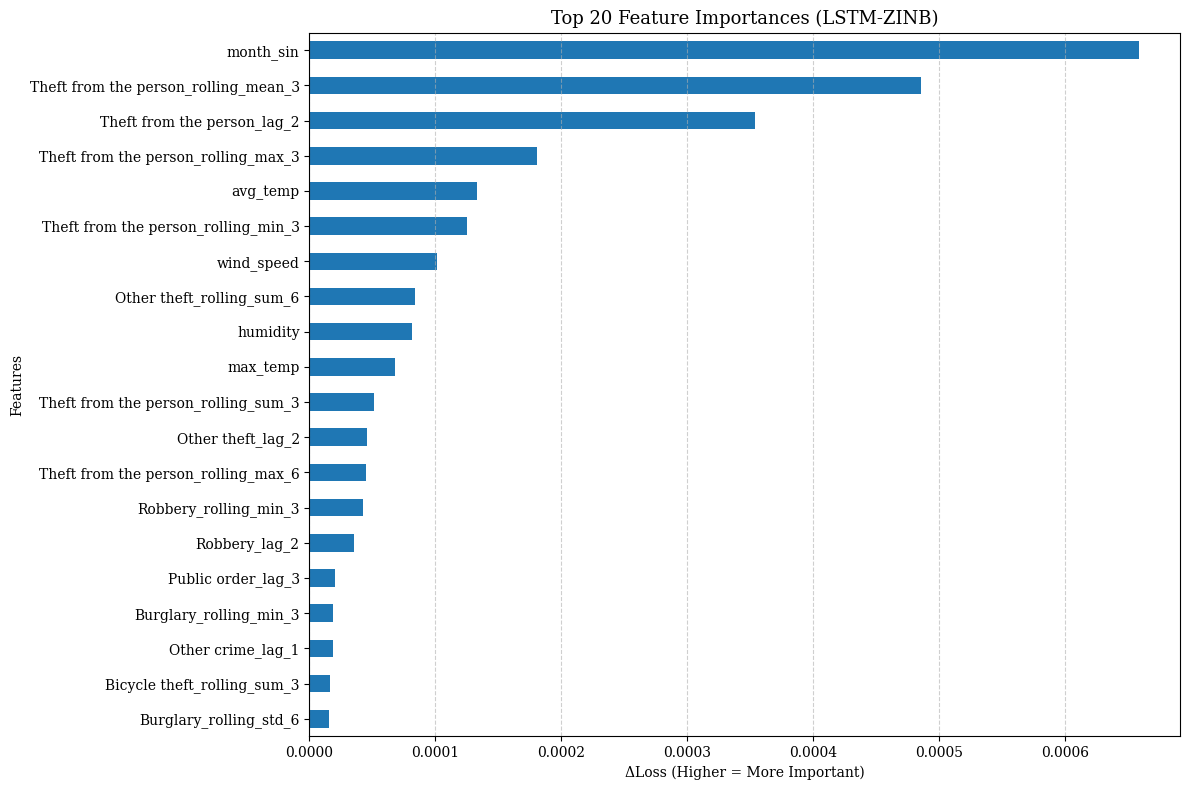

In [ ]:
top_k = 20  # show top 20 important features

plt.figure(figsize=(12, 8))
mean_importance_lstm.sort_values(ascending=True).tail(top_k).plot(
    kind="barh"
)

plt.title("Top 20 Feature Importances (LSTM-ZINB)", fontsize=13)
plt.xlabel("ΔLoss (Higher = More Important)")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

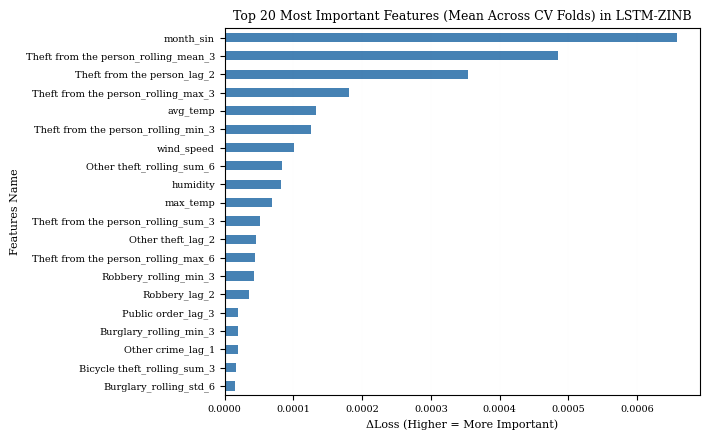

Figure saved to: /content/drive/MyDrive/lstm_feature_importance.eps


In [ ]:
import matplotlib.pyplot as plt
import os

# ----- Save location -----
save_path = "/content/drive/MyDrive/lstm_feature_importance.eps"  # change folder if needed
os.makedirs(os.path.dirname(save_path), exist_ok=True)

top_k = 20  # show top 20 important features

# ----- One-column Springer size -----
plt.figure(figsize=(7.2, 4.5))  # 3.5 in width for one column

# Plot horizontal bar chart
mean_importance_lstm.sort_values(ascending=True).tail(top_k).plot(
    kind="barh", color="steelblue"
)

# Labels
plt.title("Top 20 Most Important Features (Mean Across CV Folds) in LSTM-ZINB", fontsize=9)
plt.xlabel("ΔLoss (Higher = More Important)", fontsize=8)
plt.ylabel("Features Name", fontsize=8)

plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.grid(axis='x', linestyle="--", color="gray", linewidth=0.1, alpha=0.1)

plt.tight_layout()

# ----- Save figure -----
plt.savefig(save_path, format="eps", dpi=600, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {save_path}")

In [ ]:
BATCH = 4
EPOCHS = 30

cv_train_curves_lstm = []
cv_valid_curves_lstm = []
cv_val_losses_lstm   = []

print(f"Using {len(selected_features_lstm)} selected features\n")

for fold_idx, (train_months, valid_months) in enumerate(folds, 1):

    print(f"\n========== Fold {fold_idx} ==========")
    print("Train:", train_months[0], "→", train_months[-1])
    print("Valid:", valid_months[0], "→", valid_months[-1])

    # Split
    df_train = train_val_df[train_val_df["Month"].isin(train_months)].copy()
    df_valid = train_val_df[train_val_df["Month"].isin(valid_months)].copy()

    if df_train["Month"].nunique() < NEEDED_MONTHS or df_valid["Month"].nunique() < NEEDED_MONTHS:
        print("Skipping fold (not enough months)")
        continue

    z_cols_selected = [c for c in selected_features_lstm if c in z_columns]
    robust_cols_selected = [c for c in selected_features_lstm if c in robust_columns]

    scaler_standard = StandardScaler()
    scaler_robust   = RobustScaler(quantile_range=(10,90))

    if z_cols_selected:
        df_train[z_cols_selected] = scaler_standard.fit_transform(df_train[z_cols_selected])
        df_valid[z_cols_selected] = scaler_standard.transform(df_valid[z_cols_selected])
    if robust_cols_selected:
        df_train[robust_cols_selected] = scaler_robust.fit_transform(df_train[robust_cols_selected])
        df_valid[robust_cols_selected] = scaler_robust.transform(df_valid[robust_cols_selected])

    # Build datasets
    train_dataset = STGNNCrimeDataset(df_train, selected_features_lstm, crime_columns, SEQ_LEN, HORIZON)
    valid_dataset = STGNNCrimeDataset(df_valid, selected_features_lstm, crime_columns, SEQ_LEN, HORIZON)

    train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH, shuffle=False)

    # LSTM-ZINB Model
    model = LSTM_ZINB(
        num_features=len(selected_features_lstm),
        num_crimes=len(crime_columns),
        horizon=HORIZON,
        hidden_dim=64,
        num_layers=2,
        dropout=0.3
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

    train_curve = []
    valid_curve = []

    # Train this fold
    for epoch in range(1, EPOCHS+1):
        model.train()
        train_total, train_count = 0, 0

        for Xb, Yb in train_loader:
            Xb, Yb = Xb.to(device), Yb.to(device)

            B,T,N,F = Xb.shape
            Xb2 = Xb.permute(0,2,1,3).reshape(B*N, T, F)
            Yb2 = Yb.reshape(B*N, Yb.shape[2], Yb.shape[3])

            optimizer.zero_grad()
            pi, mu, r = model(Xb2)
            loss = zinb_nll(Yb2, pi, mu, r)
            loss.backward()
            optimizer.step()

            train_total += loss.item() * Xb2.size(0)
            train_count += Xb2.size(0)

        train_loss = train_total / train_count
        train_curve.append(train_loss)

        # Validation
        model.eval()
        valid_total, valid_count = 0, 0
        with torch.no_grad():
            for Xb, Yb in valid_loader:
                Xb, Yb = Xb.to(device), Yb.to(device)

                B,T,N,F = Xb.shape
                Xb2 = Xb.permute(0,2,1,3).reshape(B*N, T, F)
                Yb2 = Yb.reshape(B*N, Yb.shape[2], Yb.shape[3])

                pi, mu, r = model(Xb2)
                loss = zinb_nll(Yb2, pi, mu, r)

                valid_total += loss.item() * Xb2.size(0)
                valid_count += Xb2.size(0)

        valid_loss = valid_total / valid_count
        valid_curve.append(valid_loss)

        print(f"Fold {fold_idx} | Epoch {epoch}/{EPOCHS} | Train={train_loss:.4f} | Valid={valid_loss:.4f}")

    cv_train_curves_lstm.append(train_curve)
    cv_valid_curves_lstm.append(valid_curve)
    cv_val_losses_lstm.append(valid_curve[-1])

print("\n===== CV COMPLETED =====")
print("Avg Final Train Loss:", np.mean([c[-1] for c in cv_train_curves_lstm]))
print("Avg Final Valid Loss:", np.mean([c[-1] for c in cv_valid_curves_lstm]))

Using 61 selected features


========== Fold 1 ==========
Train: 2017-01 → 2018-04
Valid: 2018-05 → 2019-08
Fold 1 | Epoch 1/30 | Train=1.6762 | Valid=1.8456
Fold 1 | Epoch 2/30 | Train=1.6741 | Valid=1.8436
Fold 1 | Epoch 3/30 | Train=1.6724 | Valid=1.8415
Fold 1 | Epoch 4/30 | Train=1.6705 | Valid=1.8395
Fold 1 | Epoch 5/30 | Train=1.6691 | Valid=1.8374
Fold 1 | Epoch 6/30 | Train=1.6669 | Valid=1.8354
Fold 1 | Epoch 7/30 | Train=1.6655 | Valid=1.8333
Fold 1 | Epoch 8/30 | Train=1.6636 | Valid=1.8311
Fold 1 | Epoch 9/30 | Train=1.6615 | Valid=1.8289
Fold 1 | Epoch 10/30 | Train=1.6599 | Valid=1.8266
Fold 1 | Epoch 11/30 | Train=1.6577 | Valid=1.8242
Fold 1 | Epoch 12/30 | Train=1.6554 | Valid=1.8218
Fold 1 | Epoch 13/30 | Train=1.6534 | Valid=1.8192
Fold 1 | Epoch 14/30 | Train=1.6517 | Valid=1.8165
Fold 1 | Epoch 15/30 | Train=1.6491 | Valid=1.8137
Fold 1 | Epoch 16/30 | Train=1.6467 | Valid=1.8107
Fold 1 | Epoch 17/30 | Train=1.6451 | Valid=1.8075
Fold 1 | Epoch 18/30 | Train=1.641

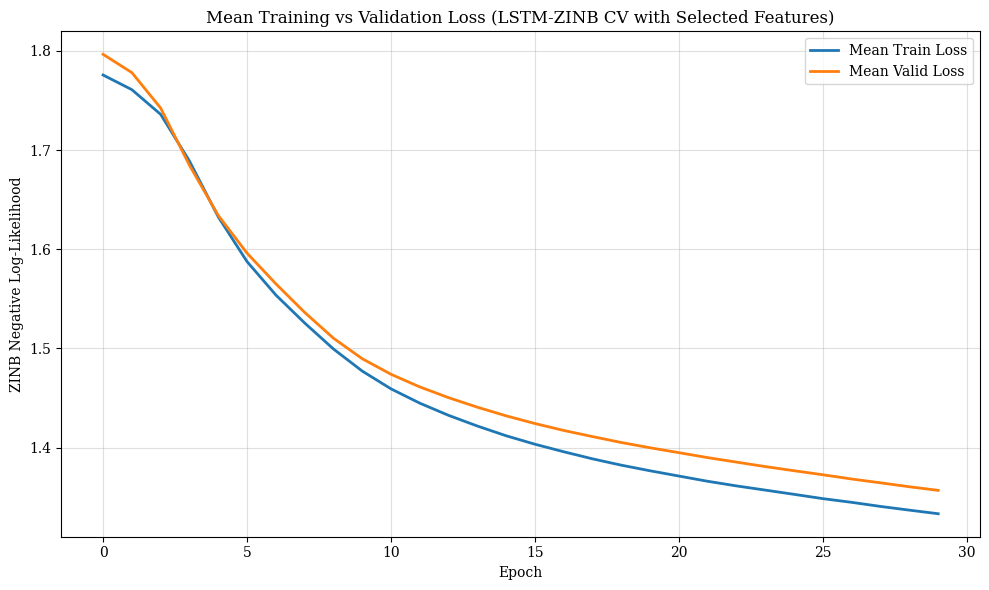

Final Mean Train Loss: 1.3333
Final Mean Valid Loss: 1.3569


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy for easier math
train_arr = np.array(cv_train_curves_lstm)   # shape: [folds, epochs]
valid_arr = np.array(cv_valid_curves_lstm)


epochs = np.arange(1, len(mean_train) + 1)

# Mean across folds
mean_train = np.mean(train_arr, axis=0)
mean_valid = np.mean(valid_arr, axis=0)

plt.figure(figsize=(10,6))
plt.plot(mean_train, label="Mean Train Loss", linewidth=2)
plt.plot(mean_valid, label="Mean Valid Loss", linewidth=2)

plt.title("Mean Training vs Validation Loss (LSTM-ZINB CV with Selected Features)")
plt.xlabel("Epoch")
plt.ylabel("ZINB Negative Log-Likelihood")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final Mean Train Loss: {mean_train[-1]:.4f}")
print(f"Final Mean Valid Loss: {mean_valid[-1]:.4f}")

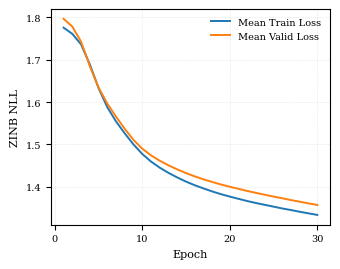

Figure saved to: /content/drive/MyDrive/lstm_cv_learning_curve_after.eps
Final Mean Train Loss: 1.3333
Final Mean Valid Loss: 1.3569


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ----- Save location -----
save_path = "/content/drive/MyDrive/lstm_cv_learning_curve_after.eps"  # change folder if needed
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# ----- Academic font -----
plt.rcParams["font.family"] = "serif"

# ----- Convert curves to numpy -----
train_arr = np.array(cv_train_curves_lstm)  # shape: [folds, epochs]
valid_arr = np.array(cv_valid_curves_lstm)

# Mean across folds
mean_train = np.mean(train_arr, axis=0)
mean_valid = np.mean(valid_arr, axis=0)

# ----- One-column figure -----
epochs = np.arange(1, len(mean_train) + 1)  # ensures curve reaches the last epoch

# ----- One-column figure -----
plt.figure(figsize=(3.5, 2.8))  # Springer one-column width

plt.plot(epochs, mean_train, label="Mean Train Loss", linewidth=1.4)
plt.plot(epochs, mean_valid, label="Mean Valid Loss", linewidth=1.4)

# Labels
plt.xlabel("Epoch", fontsize=8)
plt.ylabel("ZINB NLL", fontsize=8)

plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.grid(True, linestyle="--", color="gray", linewidth=0.4, alpha=0.2)
plt.legend(fontsize=7, frameon=False)

plt.tight_layout()

# ----- Save as EPS -----
plt.savefig(save_path, format="eps", dpi=600, bbox_inches="tight")
plt.show()

# ----- Print summary -----
print(f"Figure saved to: {save_path}")
print(f"Final Mean Train Loss: {mean_train[-1]:.4f}")
print(f"Final Mean Valid Loss: {mean_valid[-1]:.4f}")

In [ ]:
import torch
import numpy as np
from torch.utils.data import DataLoader

# --- Build Scalers using FULL train_val data ---
train_val_scaled = train_val_df.copy()
test_scaled      = test_df.copy()

z_cols_selected = [f for f in selected_features_lstm if f in z_columns]
robust_cols_selected = [f for f in selected_features_lstm if f in robust_columns]

scaler_standard = StandardScaler()
scaler_robust   = RobustScaler(quantile_range=(10, 90))

if len(z_cols_selected) > 0:
    train_val_scaled[z_cols_selected] = scaler_standard.fit_transform(train_val_scaled[z_cols_selected])
    test_scaled[z_cols_selected]      = scaler_standard.transform(test_scaled[z_cols_selected])

if len(robust_cols_selected) > 0:
    train_val_scaled[robust_cols_selected] = scaler_robust.fit_transform(train_val_scaled[robust_cols_selected])
    test_scaled[robust_cols_selected]      = scaler_robust.transform(test_scaled[robust_cols_selected])

# Create Final Datasets
final_train_dataset = STGNNCrimeDataset(
    train_val_scaled, selected_features_lstm, crime_columns,
    seq_len=SEQ_LEN, horizon=HORIZON
)
final_test_dataset = STGNNCrimeDataset(
    test_scaled, selected_features_lstm, crime_columns,
    seq_len=SEQ_LEN, horizon=HORIZON
)

final_train_loader = DataLoader(final_train_dataset, batch_size=BATCH, shuffle=True)
final_test_loader  = DataLoader(final_test_dataset, batch_size=BATCH, shuffle=False)

print(f"Train sequences: {len(final_train_dataset)}")
print(f"Test sequences:  {len(final_test_dataset)}")

# --- MODEL ---
N_nodes = final_train_dataset.X.shape[1]
F_feats = final_train_dataset.X.shape[2]

final_LSTM = LSTM_ZINB(
    num_features=F_feats,
    num_crimes=len(crime_columns),
    horizon=HORIZON,
    hidden_dim=64,
    num_layers=2,
    dropout=0.3
).to(device)

optimizer = torch.optim.AdamW(final_LSTM.parameters(), lr=3e-4, weight_decay=1e-4)

# === EARLY STOPPING ===
patience = 5
best_loss = float("inf")
wait = 0

print("\nTraining FINAL LSTM-ZINB Model...\n")

for epoch in range(1, EPOCHS+1):
    final_LSTM.train()
    train_loss_sum, train_count = 0, 0

    for Xb, Yb in final_train_loader:
        Xb, Yb = Xb.to(device), Yb.to(device)

        B,T,N,F = Xb.shape
        Xb2 = Xb.permute(0,2,1,3).reshape(B*N, T, F)
        Yb2 = Yb.reshape(B*N, Yb.shape[2], Yb.shape[3])

        optimizer.zero_grad()
        pi, mu, r = final_LSTM(Xb2)
        loss = zinb_nll(Yb2, pi, mu, r)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * Xb2.size(0)
        train_count    += Xb2.size(0)

    train_loss = train_loss_sum / train_count
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train NLL: {train_loss:.4f}")

    # Early stopping on training loss only
    if train_loss < best_loss:
        best_loss = train_loss
        wait = 0
        torch.save(final_LSTM.state_dict(), "/content/drive/MyDrive/final_LSTM_ZINB.pth")
    else:
        wait += 1
        if wait >= patience:
            print("\nEarly stopping triggered!")
            break

print(f"Best Train Loss = {best_loss:.4f}")
print("Model saved: /content/drive/MyDrive/final_LSTM_ZINB.pth")

Train sequences: 73
Test sequences:  1

Training FINAL LSTM-ZINB Model...

Epoch 01/40 | Train NLL: 1.7622
Epoch 02/40 | Train NLL: 1.6923
Epoch 03/40 | Train NLL: 1.5169
Epoch 04/40 | Train NLL: 1.4087
Epoch 05/40 | Train NLL: 1.3612
Epoch 06/40 | Train NLL: 1.3332
Epoch 07/40 | Train NLL: 1.3116
Epoch 08/40 | Train NLL: 1.2921
Epoch 09/40 | Train NLL: 1.2743
Epoch 10/40 | Train NLL: 1.2597
Epoch 11/40 | Train NLL: 1.2472
Epoch 12/40 | Train NLL: 1.2370
Epoch 13/40 | Train NLL: 1.2290
Epoch 14/40 | Train NLL: 1.2222
Epoch 15/40 | Train NLL: 1.2168
Epoch 16/40 | Train NLL: 1.2121
Epoch 17/40 | Train NLL: 1.2084
Epoch 18/40 | Train NLL: 1.2049
Epoch 19/40 | Train NLL: 1.2019
Epoch 20/40 | Train NLL: 1.1993
Epoch 21/40 | Train NLL: 1.1971
Epoch 22/40 | Train NLL: 1.1950
Epoch 23/40 | Train NLL: 1.1932
Epoch 24/40 | Train NLL: 1.1911
Epoch 25/40 | Train NLL: 1.1894
Epoch 26/40 | Train NLL: 1.1882
Epoch 27/40 | Train NLL: 1.1866
Epoch 28/40 | Train NLL: 1.1852
Epoch 29/40 | Train NLL: 1.18

In [ ]:
print("NLL per Crime Type:")
print("=" * 40)

crime_nll = {name: 0.0 for name in crime_columns}
crime_count = {name: 0 for name in crime_columns}

with torch.no_grad():
    for Xb, Yb in final_test_loader:
        Xb, Yb = Xb.to(device), Yb.to(device)

        B, T, N, F = Xb.shape

        # Consistent with training approach
        Xb2 = Xb.permute(0, 2, 1, 3).reshape(B*N, T, F)
        Yb2 = Yb.reshape(B*N, Yb.shape[2], Yb.shape[3])

        pi, mu, r = final_LSTM(Xb2)

        # Calculate NLL for each crime type separately
        for i, crime_name in enumerate(crime_columns):
            nll_values = zinb_nll(Yb2[:, :, i], pi[:, :, i], mu[:, :, i], r[:, :, i], reduction=None)
            crime_nll[crime_name] += nll_values.sum().item()
            crime_count[crime_name] += nll_values.numel()

    results = []
    for crime_name in crime_columns:
        if crime_count[crime_name] > 0:
            avg_nll = crime_nll[crime_name] / crime_count[crime_name]
            results.append((crime_name, avg_nll))

    results.sort(key=lambda x: x[1])

    for name, nll in results:
        probability = torch.exp(-torch.tensor(nll)).item()
        print(f"{name:30s}: NLL = {nll:.4f} -> p = {probability*100:.2f}%")

NLL per Crime Type:
Possession of weapons         : NLL = 0.3058 -> p = 73.65%
Other crime                   : NLL = 0.5049 -> p = 60.36%
Bicycle theft                 : NLL = 0.5198 -> p = 59.46%
Robbery                       : NLL = 0.7732 -> p = 46.16%
Shoplifting                   : NLL = 0.9911 -> p = 37.12%
Theft from the person         : NLL = 1.0357 -> p = 35.50%
Burglary                      : NLL = 1.1120 -> p = 32.89%
Drugs                         : NLL = 1.2114 -> p = 29.78%
Public order                  : NLL = 1.2198 -> p = 29.53%
Criminal damage and arson     : NLL = 1.2224 -> p = 29.45%
Other theft                   : NLL = 1.3814 -> p = 25.12%
Vehicle crime                 : NLL = 1.5190 -> p = 21.89%
Anti-social behaviour         : NLL = 2.3041 -> p = 9.99%
Violence and sexual offences  : NLL = 2.3242 -> p = 9.79%


# 4.1 Evaluation to LSTM Model

## (i) Discrete Metrics (True Zero Rate for zero-crime cases & F1-Score for crime-occurred cases)

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

LSTM_ZINBmodel.eval()

all_y_true = []
all_y_pred = []

with torch.no_grad():
    for Xb, Yb in final_test_loader:
        Xb = Xb.to(device)
        Yb = Yb.to(device)

        B,T,N,F = Xb.shape
        Xb2 = Xb.permute(0,2,1,3).reshape(B*N, T, F)  # [B*N,T,F]
        Yb2 = Yb.reshape(B*N, Yb.shape[2], Yb.shape[3]) # [B*N,H,C]

        pi, mu, r = final_LSTM(Xb2)

        # predicted mean count = (1-pi)*mu
        y_pred = (1 - pi) * mu

        y_true = Yb2.cpu().numpy().astype(np.float64)
        y_pred = y_pred.cpu().numpy().astype(np.float64)

        y_true = np.clip(y_true, 0, None)
        y_pred = np.clip(y_pred, 0, None)

        all_y_true.append(y_true)
        all_y_pred.append(y_pred)

y_true_all = np.concatenate(all_y_true, axis=0)   # [samples,H,C]
y_pred_all = np.concatenate(all_y_pred, axis=0)

tzr_f1_list = []

for i, crime in enumerate(crime_columns):
    y_true_flat = y_true_all[..., i].ravel()
    y_pred_flat = y_pred_all[..., i].ravel()

    # binary labels
    y_true_bin = (y_true_flat > 0).astype(int)
    y_pred_bin = (y_pred_flat > 0.5).astype(int)   # threshold 0.5 count

    # True Zero Rate
    zero_mask = (y_true_flat == 0)
    if zero_mask.sum() > 0:
        correct_zeros = np.sum((y_pred_bin == 0) & zero_mask)
        tzr = correct_zeros / zero_mask.sum()
    else:
        tzr = np.nan

    # F1
    if len(np.unique(y_true_bin)) > 1:
        f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    else:
        f1 = np.nan

    tzr_f1_list.append((crime, tzr, f1))

# sort by F1 best
valid_metrics = [x for x in tzr_f1_list if not np.isnan(x[1]) and not np.isnan(x[2])]
tzr_f1_sorted = sorted(valid_metrics, key=lambda x: x[2], reverse=True)

print("LSTM-ZINB  |  True Zero Rate & F1")
print(f"{'Crime Type':30s} | {'TZR':>8s} | {'F1':>8s}")
print("-" * 55)
for c,z,f in tzr_f1_sorted:
    print(f"{c:30s} | {z:8.3f} | {f:8.3f}")

print("\nGlobal averages:")
print(f"TZR = {np.nanmean([z for _,z,_ in tzr_f1_sorted]):.3f}")
print(f"F1  = {np.nanmean([f for _,_,f in tzr_f1_sorted]):.3f}")

LSTM-ZINB  |  True Zero Rate & F1
Crime Type                     |      TZR |       F1
-------------------------------------------------------
Violence and sexual offences   |    0.106 |    0.939
Anti-social behaviour          |    0.095 |    0.920
Vehicle crime                  |    0.034 |    0.787
Other theft                    |    0.377 |    0.743
Criminal damage and arson      |    0.404 |    0.699
Public order                   |    0.539 |    0.688
Shoplifting                    |    0.814 |    0.631
Burglary                       |    0.166 |    0.617
Theft from the person          |    0.867 |    0.608
Drugs                          |    0.686 |    0.604
Robbery                        |    0.820 |    0.557
Bicycle theft                  |    0.859 |    0.437
Possession of weapons          |    0.993 |    0.113
Other crime                    |    0.987 |    0.097

Global averages:
TZR = 0.553
F1  = 0.603


# (ii) Uncertainty Metrics - KL Divergence (Kullback-Leibler Divergence)

In [ ]:
kl_list = []

with torch.no_grad():
    all_y_true = []
    all_pi = []
    all_mu = []
    all_r  = []

    for Xb, Yb in final_test_loader:
        Xb = Xb.to(device)
        Yb = Yb.to(device)

        B,T,N,F = Xb.shape

        Xb2 = Xb.permute(0,2,1,3).reshape(B*N, T, F)  # [B*N,T,F]
        Yb2 = Yb.reshape(B*N, Yb.shape[2], Yb.shape[3])

        pi, mu, r = final_LSTM(Xb2)

        all_y_true.append(Yb2.cpu())
        all_pi.append(pi.cpu())
        all_mu.append(mu.cpu())
        all_r.append(r.cpu())

y_true_all = torch.cat(all_y_true, dim=0)  # [samples,H,C]
pi_all     = torch.cat(all_pi,   dim=0)
mu_all     = torch.cat(all_mu,   dim=0)
r_all      = torch.cat(all_r,    dim=0)

for i, crime in enumerate(crime_columns):
    kl = zinb_nll(
        y_true_all[..., i],
        pi_all[..., i],
        mu_all[..., i],
        r_all[..., i],
        reduction="mean"
    ).item()
    kl_list.append((crime, kl))

kl_sorted = sorted(kl_list, key=lambda x: x[1])

print("KL Divergence per Crime Type")
print(f"{'Crime Type':30s} | {'KL':>8s}")
print("-" * 42)
for c,v in kl_sorted:
    print(f"{c:30s} | {v:8.3f}")

print("\nGlobal Mean KL:", np.mean([v for _, v in kl_sorted]))

KL Divergence per Crime Type
Crime Type                     |       KL
------------------------------------------
Possession of weapons          |    0.306
Other crime                    |    0.501
Bicycle theft                  |    0.517
Robbery                        |    0.773
Shoplifting                    |    0.997
Theft from the person          |    1.033
Burglary                       |    1.114
Drugs                          |    1.215
Public order                   |    1.221
Criminal damage and arson      |    1.225
Other theft                    |    1.380
Vehicle crime                  |    1.519
Anti-social behaviour          |    2.306
Violence and sexual offences   |    2.324

Global Mean KL: 1.173591896891594
